# Assessing PDI squared-difference losses
Based on `testing_polarimetry.ipynb`, using production functions from `lib` instead of copied implementations. No MCFOST simulations are launched.

The score is `(fraction + radial + quadrant)/3`: squared positive-Qphi/I fraction difference, **mean** squared normalised Qphi radial-bin difference, and **sum** of six squared differential-quadrant differences. There are no error divisors. I(r) remains diagnostic. These are mismatch scores, not chi-squared values. Compare individual terms before choosing any future weights; this notebook does not change production weights.

The synthetic section runs without observational files. Set paths in the real-data section to compare existing models with the observed PSF and the same unresolved-correction setting used in production. Fresh outputs go to `pdi_loss_assessment/`.

In [11]:
from pathlib import Path
import sys, copy, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / 'lib').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'lib/obriy_polarimetry.py').is_file():
    raise RuntimeError('Run from the repository root or a folder directly below it.')
sys.path.insert(0, str(ROOT))
from lib import obriy_polarimetry as obp
from lib import obriy_general as obg
import importlib
importlib.reload(obp)  # Pick up current library edits when rerunning this notebook.
OUTPUT = ROOT / 'pdi_loss_assessment'
OUTPUT.mkdir(exist_ok=True)

/Users/katerynaandrych/Work/lin/python scripts/modelling_optimisation/lib/obriy_polarimetry.py:216: SyntaxWarning: invalid escape sequence '\m'
  plt.suptitle(str(wave)+"$\mu m$, "+title_addition)


## Synthetic checks and sensitivity
Construct a tangentially polarised source on one grid. Check zero loss for an identical model, invariance under common flux scaling, and response to polarised-amplitude, radial-width and azimuthal-asymmetry changes. These are measurement-sensitivity tests, not physical MCFOST parameter fits.

PASS: identical model and common-flux-scale invariance.


,parameter,value,fraction,radial,quadrant,loss,seconds
0,amplitude,0.50,6.213958e+03,0.000000e+00,0.000000e+00,6.213958e+03,0.007344
1,amplitude,0.60,3.976933e+03,2.271380e-25,4.622232e-30,3.976933e+03,0.006307
2,amplitude,0.70,2.237025e+03,1.413232e-25,7.703720e-30,2.237025e+03,0.006483
3,amplitude,0.80,9.942333e+02,1.612800e-25,8.474092e-30,9.942333e+02,0.005561
4,amplitude,0.90,2.485583e+02,4.159381e-26,1.155558e-29,2.485583e+02,0.007600
5,amplitude,1.00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.005768
6,amplitude,1.10,2.485583e+02,2.999722e-26,1.694818e-29,2.485583e+02,0.006286
7,amplitude,1.20,9.942333e+02,2.271247e-25,9.244464e-30,9.942333e+02,0.005494
8,amplitude,1.30,2.237025e+03,4.162174e-26,1.540744e-30,2.237025e+03,0.007178
9,amplitude,1.40,3.976933e+03,1.413232e-25,7.703720e-30,3.976933e+03,0.006179


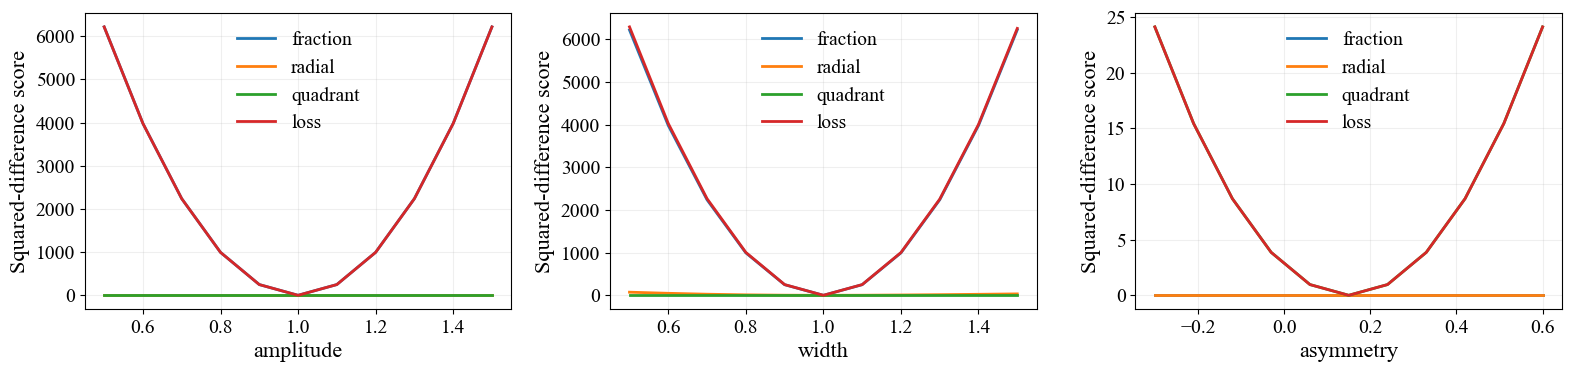

In [12]:
N, PIXEL_MAS, PA = 129, 3.6, 25.0
R, _, _, X, Y = obp.compute_grid(np.zeros((N,N)))
phi = np.arctan2(Y, X) + np.pi/2
radius_mas = R * PIXEL_MAS

def synthetic_model(amplitude=1., width=1., asymmetry=.15):
    qp = amplitude * np.exp(-((radius_mas-80)/(25*width))**2) * (1+asymmetry*np.cos(phi))
    qp[R == 0] = 0
    intensity = 20*np.exp(-(radius_mas/15)**2) + 3*np.exp(-radius_mas/100)
    return dict(q_phi=qp, img_q=-qp*np.cos(2*phi),
                img_u=-qp*np.sin(2*phi), img_tot=intensity)

reference = synthetic_model()
observation = dict(Q_phi=reference['q_phi'], U_phi=np.zeros((N,N)), I=reference['img_tot'])
identical = obp.compare_pdi_constraints(observation, reference, PIXEL_MAS, disk_pa_deg=PA)
assert np.isclose(identical['loss'], 0, atol=1e-24)
scaled = {key: value*3 for key,value in reference.items()}
assert np.isclose(obp.compare_pdi_constraints(observation, scaled, PIXEL_MAS, disk_pa_deg=PA)['loss'], 0, atol=1e-24)
print('PASS: identical model and common-flux-scale invariance.')

rows = []
for parameter, values in [('amplitude', np.linspace(.5,1.5,11)),
                          ('width', np.linspace(.5,1.5,11)),
                          ('asymmetry', np.linspace(-.3,.6,11))]:
    for value in values:
        start = time.perf_counter()
        result = obp.compare_pdi_constraints(observation, synthetic_model(**{parameter:value}), PIXEL_MAS, disk_pa_deg=PA)
        rows.append(dict(parameter=parameter, value=value,
                         **{key:result[key] for key in ('fraction','radial','quadrant','loss')},
                         seconds=time.perf_counter()-start))
sensitivity = pd.DataFrame(rows)
display(sensitivity)
fig, axes = plt.subplots(1,3,figsize=(16,4))
for ax, (parameter, group) in zip(axes, sensitivity.groupby('parameter',sort=False)):
    for term in ('fraction','radial','quadrant','loss'):
        ax.plot(group.value,group[term],label=term)
    ax.set(xlabel=parameter,ylabel='Squared-difference score'); ax.legend(); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()
sensitivity.to_csv(OUTPUT/'synthetic_sensitivity.csv',index=False)

## Existing models and observations
The model and observation paths are configured below. The **simulation PA** is read from saved model metadata; it may also be supplied explicitly. Set `CORRECT_UNRESOLVED` to match the observations' reduction state. If enabled, give the same correction radius as production. The FITS images are loaded directly from `POL_DATA_ROOT` using the library loader.

The source notebook used a synthetic 40 mas PSF; this section uses each band's observed PSF to match production. The shared aperture is recorded: comparing rankings across different aperture radii is not a fixed-data comparison.

V {'Q_phi': (1024, 1024), 'U_phi': (1024, 1024), 'I': (1024, 1024)} PSF: /Users/katerynaandrych/Work/lin/Postdoc/Data/polarimetry/IRAS08544-4431_for_modelling/psf/HD83878_V_I_meancombined.fits
I {'Q_phi': (1024, 1024), 'U_phi': (1024, 1024), 'I': (1024, 1024)} PSF: /Users/katerynaandrych/Work/lin/Postdoc/Data/polarimetry/IRAS08544-4431_for_modelling/psf/HD83878_I_I_meancombined.fits
H {'Q_phi': (1024, 1024), 'U_phi': (1024, 1024), 'I': (1024, 1024)} PSF: /Users/katerynaandrych/Work/lin/Postdoc/Data/polarimetry/IRAS08544-4431_for_modelling/psf/iras08544-4431_calib_H_I_meancombined.fits
Native pixel scale: 0.683 mas/pix
Native pixel number: 600 pix
Native FoV: 409.836 mas (409.836 au)
Instrument pixel scale: 3.600 mas/pix
Instrument pixel number: 114 pix
New FoV: 410.400 mas (410.400 au)
Convolving with real PSF from observations
PSF shape: (200, 200), PSF sum: 1.0
new shape after convolution: (114, 114)


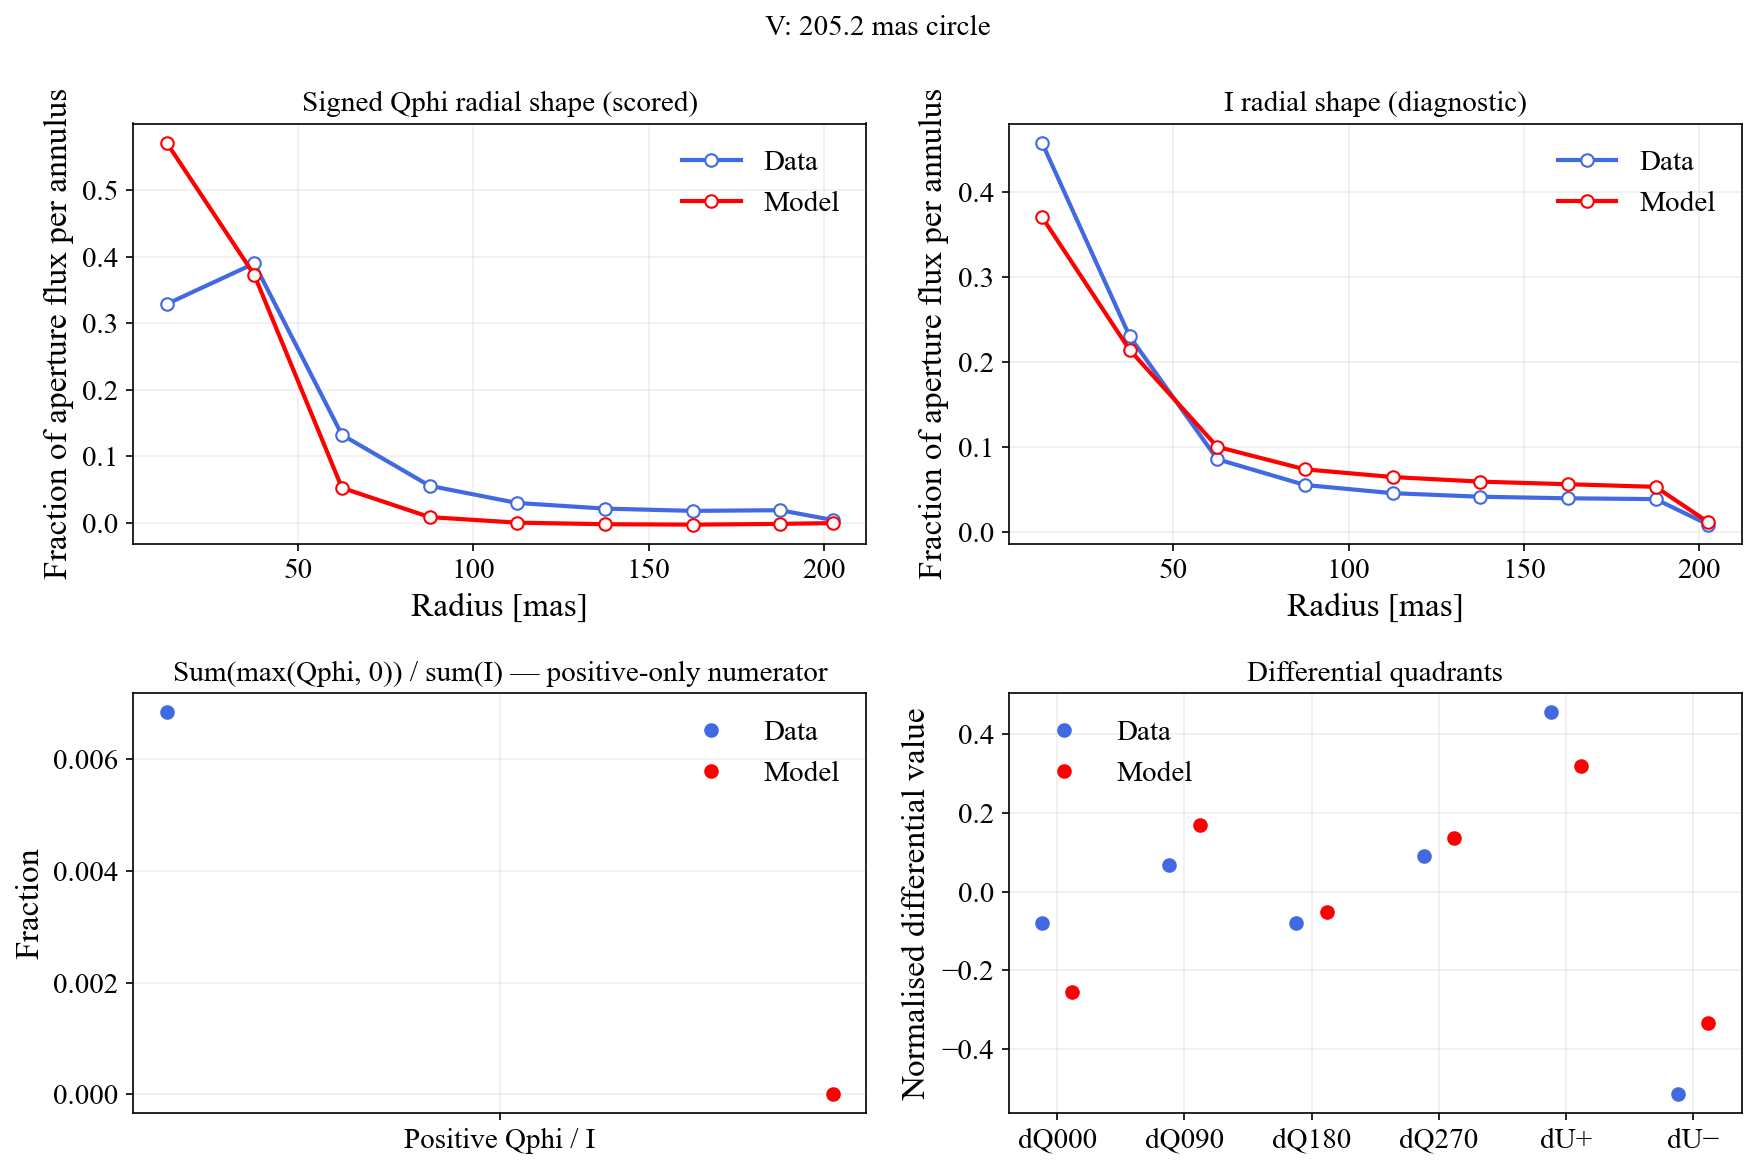

Native pixel scale: 0.683 mas/pix
Native pixel number: 600 pix
Native FoV: 409.836 mas (409.836 au)
Instrument pixel scale: 3.600 mas/pix
Instrument pixel number: 114 pix
New FoV: 410.400 mas (410.400 au)
Convolving with real PSF from observations
PSF shape: (200, 200), PSF sum: 1.0
new shape after convolution: (114, 114)


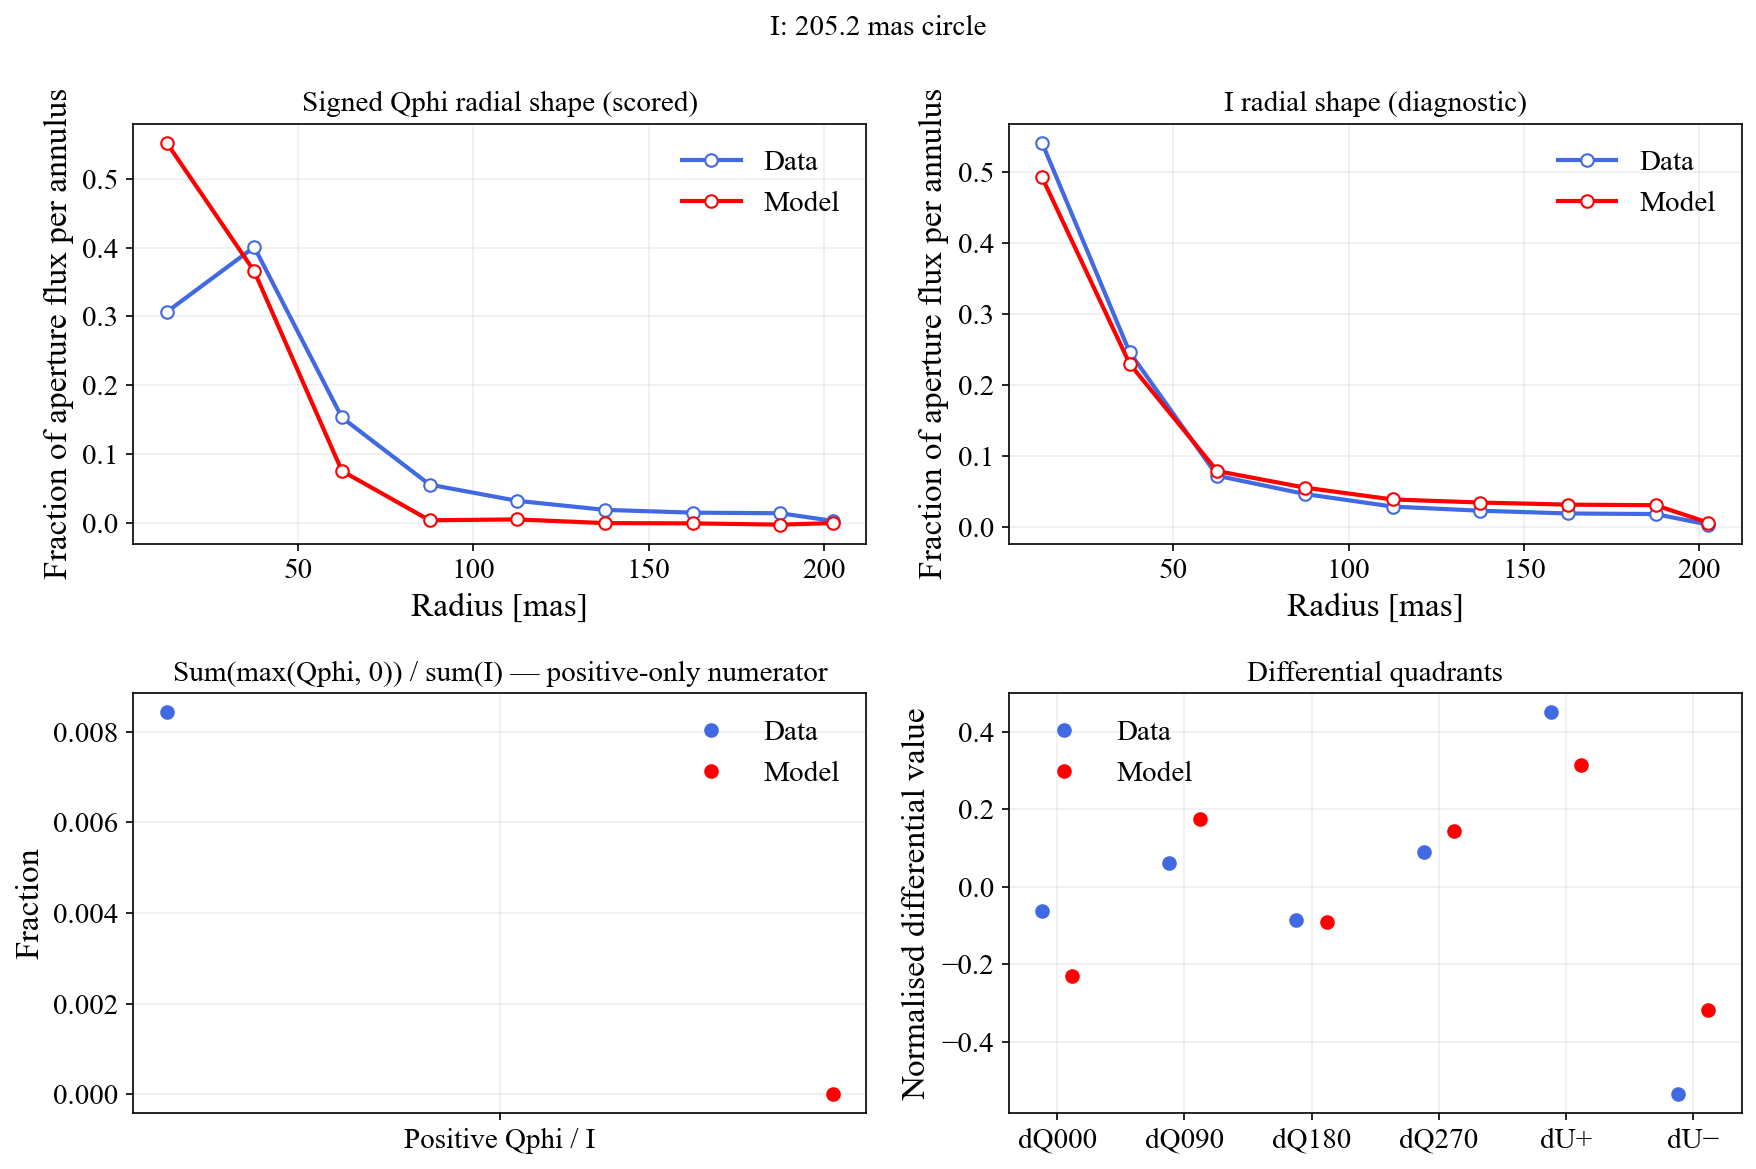

Native pixel scale: 0.683 mas/pix
Native pixel number: 600 pix
Native FoV: 409.836 mas (409.836 au)
Instrument pixel scale: 12.270 mas/pix
Instrument pixel number: 33 pix
New FoV: 404.910 mas (404.910 au)
Convolving with real PSF from observations
PSF shape: (200, 200), PSF sum: 0.9999999403953552
new shape after convolution: (33, 33)
[obriy_polarimetry] ROI half size 30 too large for image shape (33, 33). Disabling cropping for plot.
[obriy_polarimetry] ROI half size 30 too large for image shape (33, 33). Disabling cropping for plot.
[obriy_polarimetry] ROI half size 30 too large for image shape (33, 33). Disabling cropping for plot.
[obriy_polarimetry] ROI half size 30 too large for image shape (33, 33). Disabling cropping for plot.


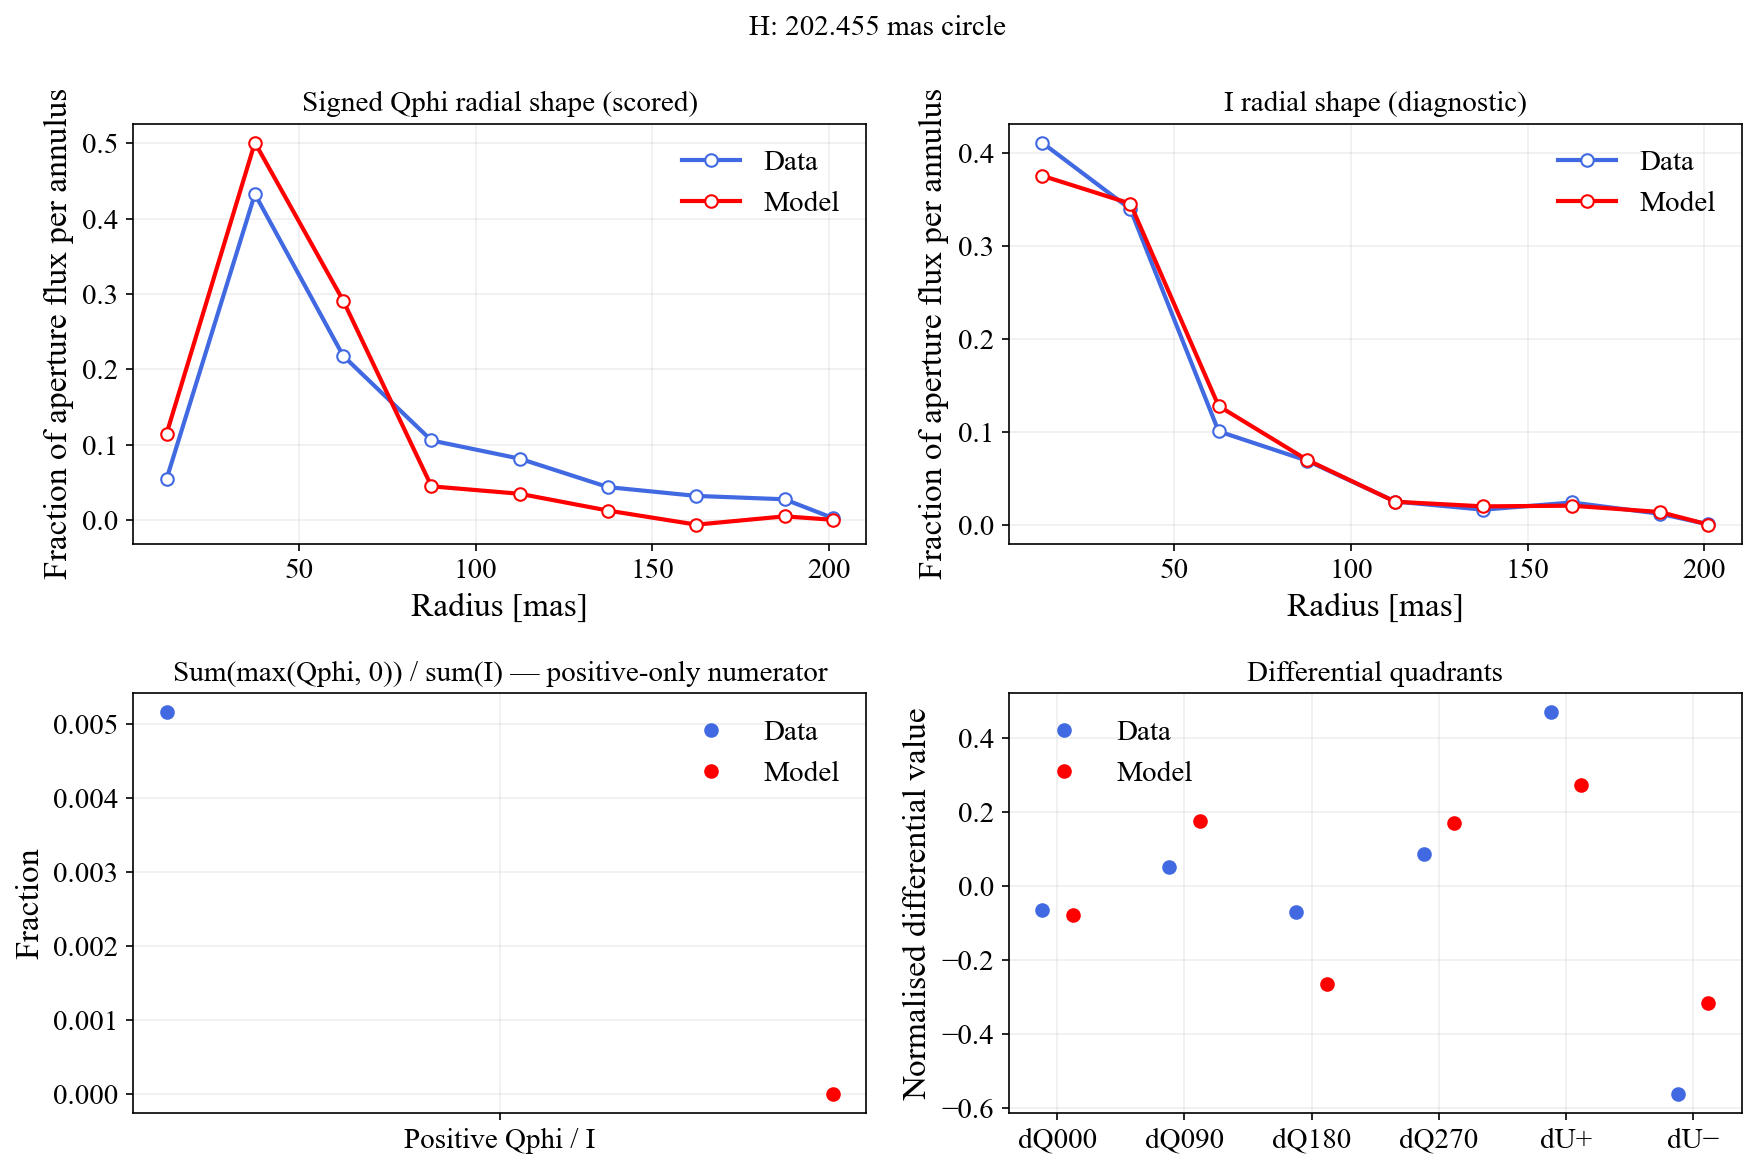

In [13]:
RUN_REAL_DATA = True
folder = '/Users/katerynaandrych/Work/lin/Postdoc/ozstar/ozstar_model/trial_seed1562913011_budget14.10_20260805-233423/'
POL_DATA_ROOT = Path('/Users/katerynaandrych/Work/lin/Postdoc/Data/polarimetry/IRAS08544-4431_for_modelling/')
SED_DATA_ROOT = Path('/Users/katerynaandrych/Work/lin/Postdoc/Data/SED_reddening/IRAS08544-4431')
SED_PHOTOMETRY = SED_DATA_ROOT / 'IRAS08544-4431.phot'
SED_IF_REPO = ROOT
SED_IF_LAW = SED_IF_REPO / 'utils/ISMreddening_law_Cardelli1989.dat'
# SED paths are reference settings; SED/extinction do not enter this PDI loss.
BANDS = ['V', 'I', 'H']
MODELS = [{'label': 'existing_best_model', 'path': folder, 'disk_pa_deg': 6}]
# Files below are corrected for unresolved polarisation. Supply the production radius.
CORRECT_UNRESOLVED = True
CORRECTION_RADIUS_PX = 3
RADIAL_BIN_MAS = 25.0
SETUP = {'V': (5,.55,'zimpol'), 'I': (6,.82,'zimpol'), 'H': (7,1.63,'irdis')}
real_results, real_rows, prepared_models = {}, [], {}
# Direct observation loading avoids SMAC3's machine-specific data selectors.
data = {}
for band in BANDS:
    slot, _, _ = SETUP[band]
    prefix = f'IRAS08544-4431_dc_notnorm_{band}' if band != 'H' else 'iras08544-4431_calib_H'
    suffix = 'corr_tel+unres' if CORRECT_UNRESOLVED else 'meancombined'
    files = {key: POL_DATA_ROOT / f'{band}_band' / f'{prefix}_{key}_{suffix}.fits'
             for key in ('Q_phi', 'U_phi')}
    files['I'] = POL_DATA_ROOT / f'{band}_band' / f'{prefix}_I_meancombined.fits'
    psf_path = POL_DATA_ROOT / 'psf' / (
        f'HD83878_{band}_I_meancombined.fits' if band != 'H' else 'iras08544-4431_calib_H_I_meancombined.fits')
    for path in [*files.values(), psf_path]:
        if not path.is_file():
            raise FileNotFoundError(f'Missing observational file: {path}')
    pol_images = {key: obp.Loadimage(str(path.parent)+'/', path.name) for key,path in files.items()}
    data[slot] = dict(pol_images=pol_images, psf=obp.Loadimage(str(psf_path.parent)+'/', psf_path.name))
    print(band, {key: value.shape for key,value in pol_images.items()}, 'PSF:', psf_path)

missing_models = [model['path'] for model in MODELS if not Path(model['path']).is_dir()]
if RUN_REAL_DATA and missing_models:
    print('SKIPPED model comparison: model folder not accessible on this machine:', missing_models)
    print('Mount/copy the model locally and update folder, or run where both roots are accessible.')
if RUN_REAL_DATA and not missing_models:
    if not MODELS:
        raise ValueError('Provide at least one existing model directory and its PA.')
    for model in MODELS:
        if model['disk_pa_deg'] is None:
            config_path = Path(model['path']) / 'config_used.json'
            if config_path.is_file():
                saved = json.loads(config_path.read_text())
                model['disk_pa_deg'] = saved.get('cfg', saved).get('disk_pa')
            if model['disk_pa_deg'] is None:
                from lib.obriy_mcfost import ParaFile
                parameter_file = Path(model['path']) / 'model.para'
                if parameter_file.is_file():
                    model['disk_pa_deg'] = ParaFile(str(parameter_file)).params.get('disk_pa')
            if model['disk_pa_deg'] is None:
                raise ValueError('Set disk_pa_deg from the simulation; no saved PA was found.')
            model['disk_pa_deg'] = float(model['disk_pa_deg'])
    correction_radius = obp.unresolved_correction_radius(CORRECT_UNRESOLVED, CORRECTION_RADIUS_PX)
    key = 'mcfost_convolved_unresolved_corrected' if CORRECT_UNRESOLVED else 'mcfost_convolved'
    for index, model in enumerate(MODELS):
        for band in BANDS:
            slot, wavelength, camera = SETUP[band]
            target = OUTPUT / f'model_{index}_{band}'
            target.mkdir(exist_ok=True)
            start = time.perf_counter()
            prepared = obp.polarimetric_analysis(
                str(Path(model['path'])), wavelength, camera=camera,
                convolution_mode='file', psf_array=data[slot]['psf'], psf_cut=100,
                unresolved_correction_radius_px=correction_radius,
                plot=False, fig_dir=str(target)+'/', extra_title=band)
            prepared_models[(index, band)] = prepared
            preprocessing_seconds = time.perf_counter()-start
            start = time.perf_counter()
            result = obp.compare_pdi_constraints(
                data[slot]['pol_images'], prepared[key], prepared[key]['pixel_scale_mas'],
                radial_bin_mas=RADIAL_BIN_MAS, disk_pa_deg=model['disk_pa_deg'])
            scoring_seconds = time.perf_counter()-start
            real_results[(index,band)] = result
            real_rows.append(dict(model=model['label'], band=band,
                **{term:result[term] for term in ('fraction','radial','quadrant','loss')},
                aperture_mas=result['aperture_radius_mas'], preprocessing_seconds=preprocessing_seconds,
                scoring_seconds=scoring_seconds))
            # Use the production plot, timing scoring separately from rendering.
            plot_path = target/'constraints.png'
            with obg.diagnostic_plot(f'{band}: scored PDI constraints'):
                obp.plot_pdi_constraints(result['observed'],result['model'],plot_path,band)
                display(Image(filename=str(plot_path)))
elif not RUN_REAL_DATA:
    print('Real-data model assessment disabled.')

,model,band,fraction,radial,quadrant,loss,aperture_mas,preprocessing_seconds,scoring_seconds
0,existing_best_model,V,46.735174,77.734057,95.696412,220.165643,205.200,0.083314,0.179176
1,existing_best_model,I,70.980793,80.145975,110.811213,261.937981,205.200,0.088035,0.187192
2,existing_best_model,H,26.529938,24.925231,160.785242,212.240410,202.455,0.177122,0.179627


,fraction,radial,quadrant,loss
model,,,,
existing_best_model,144.245905,182.805262,367.292867,694.344034


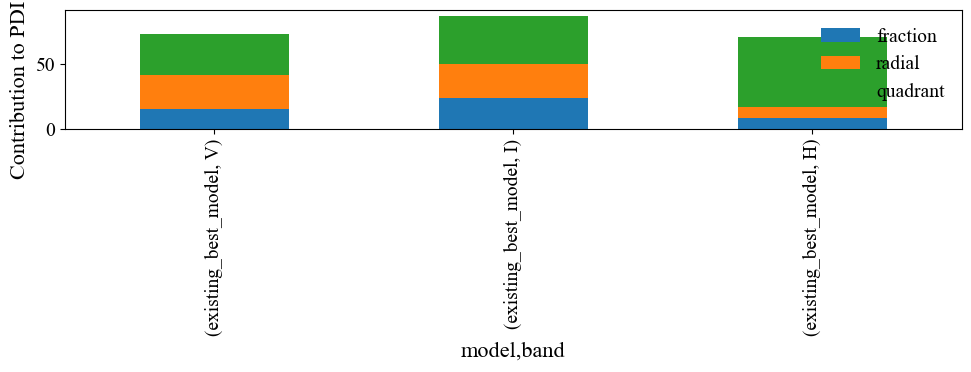

,quadrant,observed,model,squared_difference
0,dQ000_norm,-0.079393,-0.255367,0.030967
1,dQ090_norm,0.068052,0.169231,0.010237
2,dQ180_norm,-0.079416,-0.051479,0.000780
3,dQ270_norm,0.090757,0.137615,0.002196
4,dUplus_norm,0.456229,0.320193,0.018506
5,dUminus_norm,-0.515275,-0.333589,0.033010


,quadrant,observed,model,squared_difference
0,dQ000_norm,-0.063456,-0.230911,0.028041
1,dQ090_norm,0.060329,0.175976,0.013374
2,dQ180_norm,-0.086045,-0.089783,0.000014
3,dQ270_norm,0.089173,0.144718,0.003085
4,dUplus_norm,0.450420,0.313683,0.018697
5,dUminus_norm,-0.535073,-0.316899,0.047600


,quadrant,observed,model,squared_difference
0,dQ000_norm,-0.064605,-0.078339,0.000189
1,dQ090_norm,0.049830,0.174716,0.015597
2,dQ180_norm,-0.070048,-0.265959,0.038381
3,dQ270_norm,0.084823,0.169582,0.007184
4,dUplus_norm,0.469483,0.272380,0.038850
5,dUminus_norm,-0.563984,-0.317843,0.060585


In [14]:
if real_rows:
    scores = pd.DataFrame(real_rows)
    display(scores)
    display(scores.groupby('model')[['fraction','radial','quadrant','loss']].sum())
    contributions = scores.set_index(['model','band'])[['fraction','radial','quadrant']]/3
    contributions.plot.bar(stacked=True, ylabel='Contribution to PDI loss', figsize=(10,4))
    plt.tight_layout(); plt.show()
    scores.to_csv(OUTPUT/'model_loss_components.csv',index=False)
    with (OUTPUT/'model_measurements.json').open('w') as stream:
        json.dump({f'{index}_{band}':r for (index,band),r in real_results.items()},stream,indent=2)
    for (index,band),result in real_results.items():
        display(pd.DataFrame({'quadrant':obp.PDI_QUADRANT_KEYS,
            'observed':result['observed']['quadrants'], 'model':result['model']['quadrants'],
            'squared_difference':(np.array(result['model']['quadrants'])-result['observed']['quadrants'])**2}))
    if scores.groupby('band').aperture_mas.nunique().max()>1:
        print('WARNING: model coverage changed the aperture between trials; do not interpret these rankings as fixed-aperture fits.')
else:
    print('No completed comparisons. Run the data/model cell and check any reported errors.')


## Library diagnostics of the scored images
Run after the real-model comparison. Reuse cached model products: no repeated model loading or convolution. Image stages use their own pixel scales. Quadrant maps use the **scoring aperture and simulation PA**, with the same observational Q/U reconstruction and model correction state as production. Assertions compare the six diagnostic values to the stored scoring values before plotting.

Raw quadrant fluxes in observation and model may have different units; only the normalised quantities are compared numerically. No independent notebook copies of plotting or quadrant functions are used.

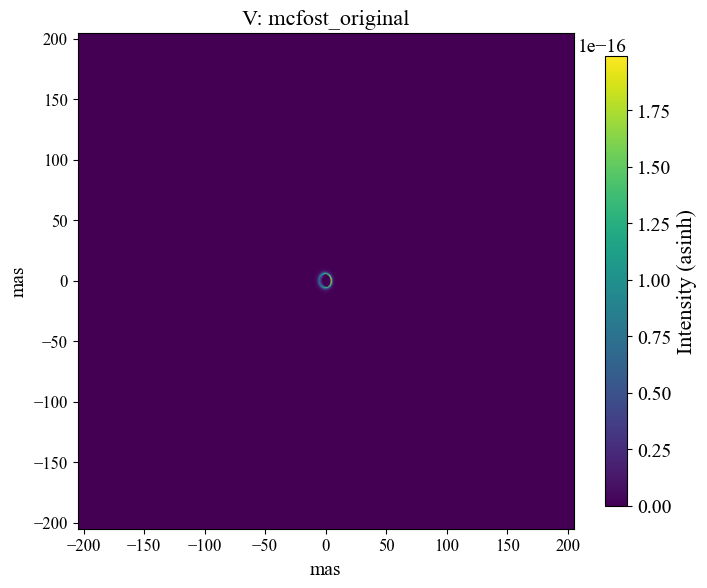

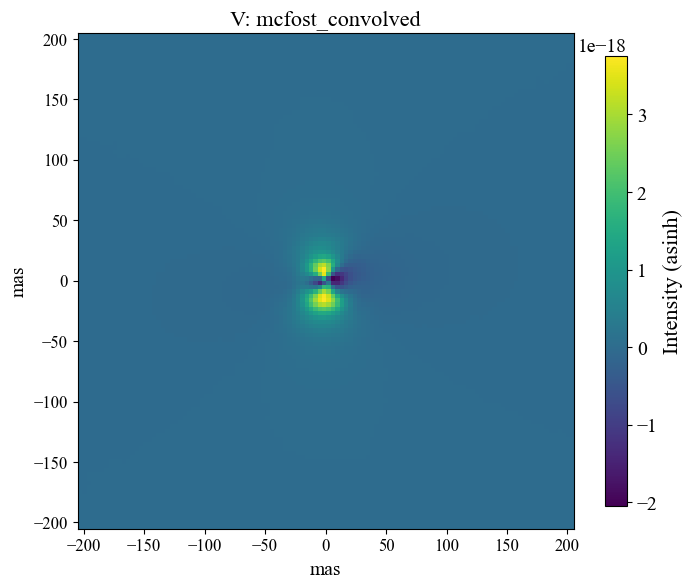

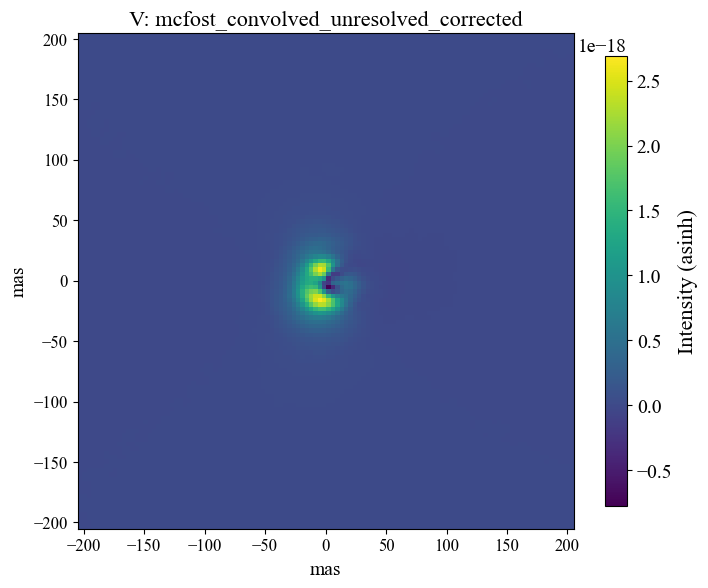

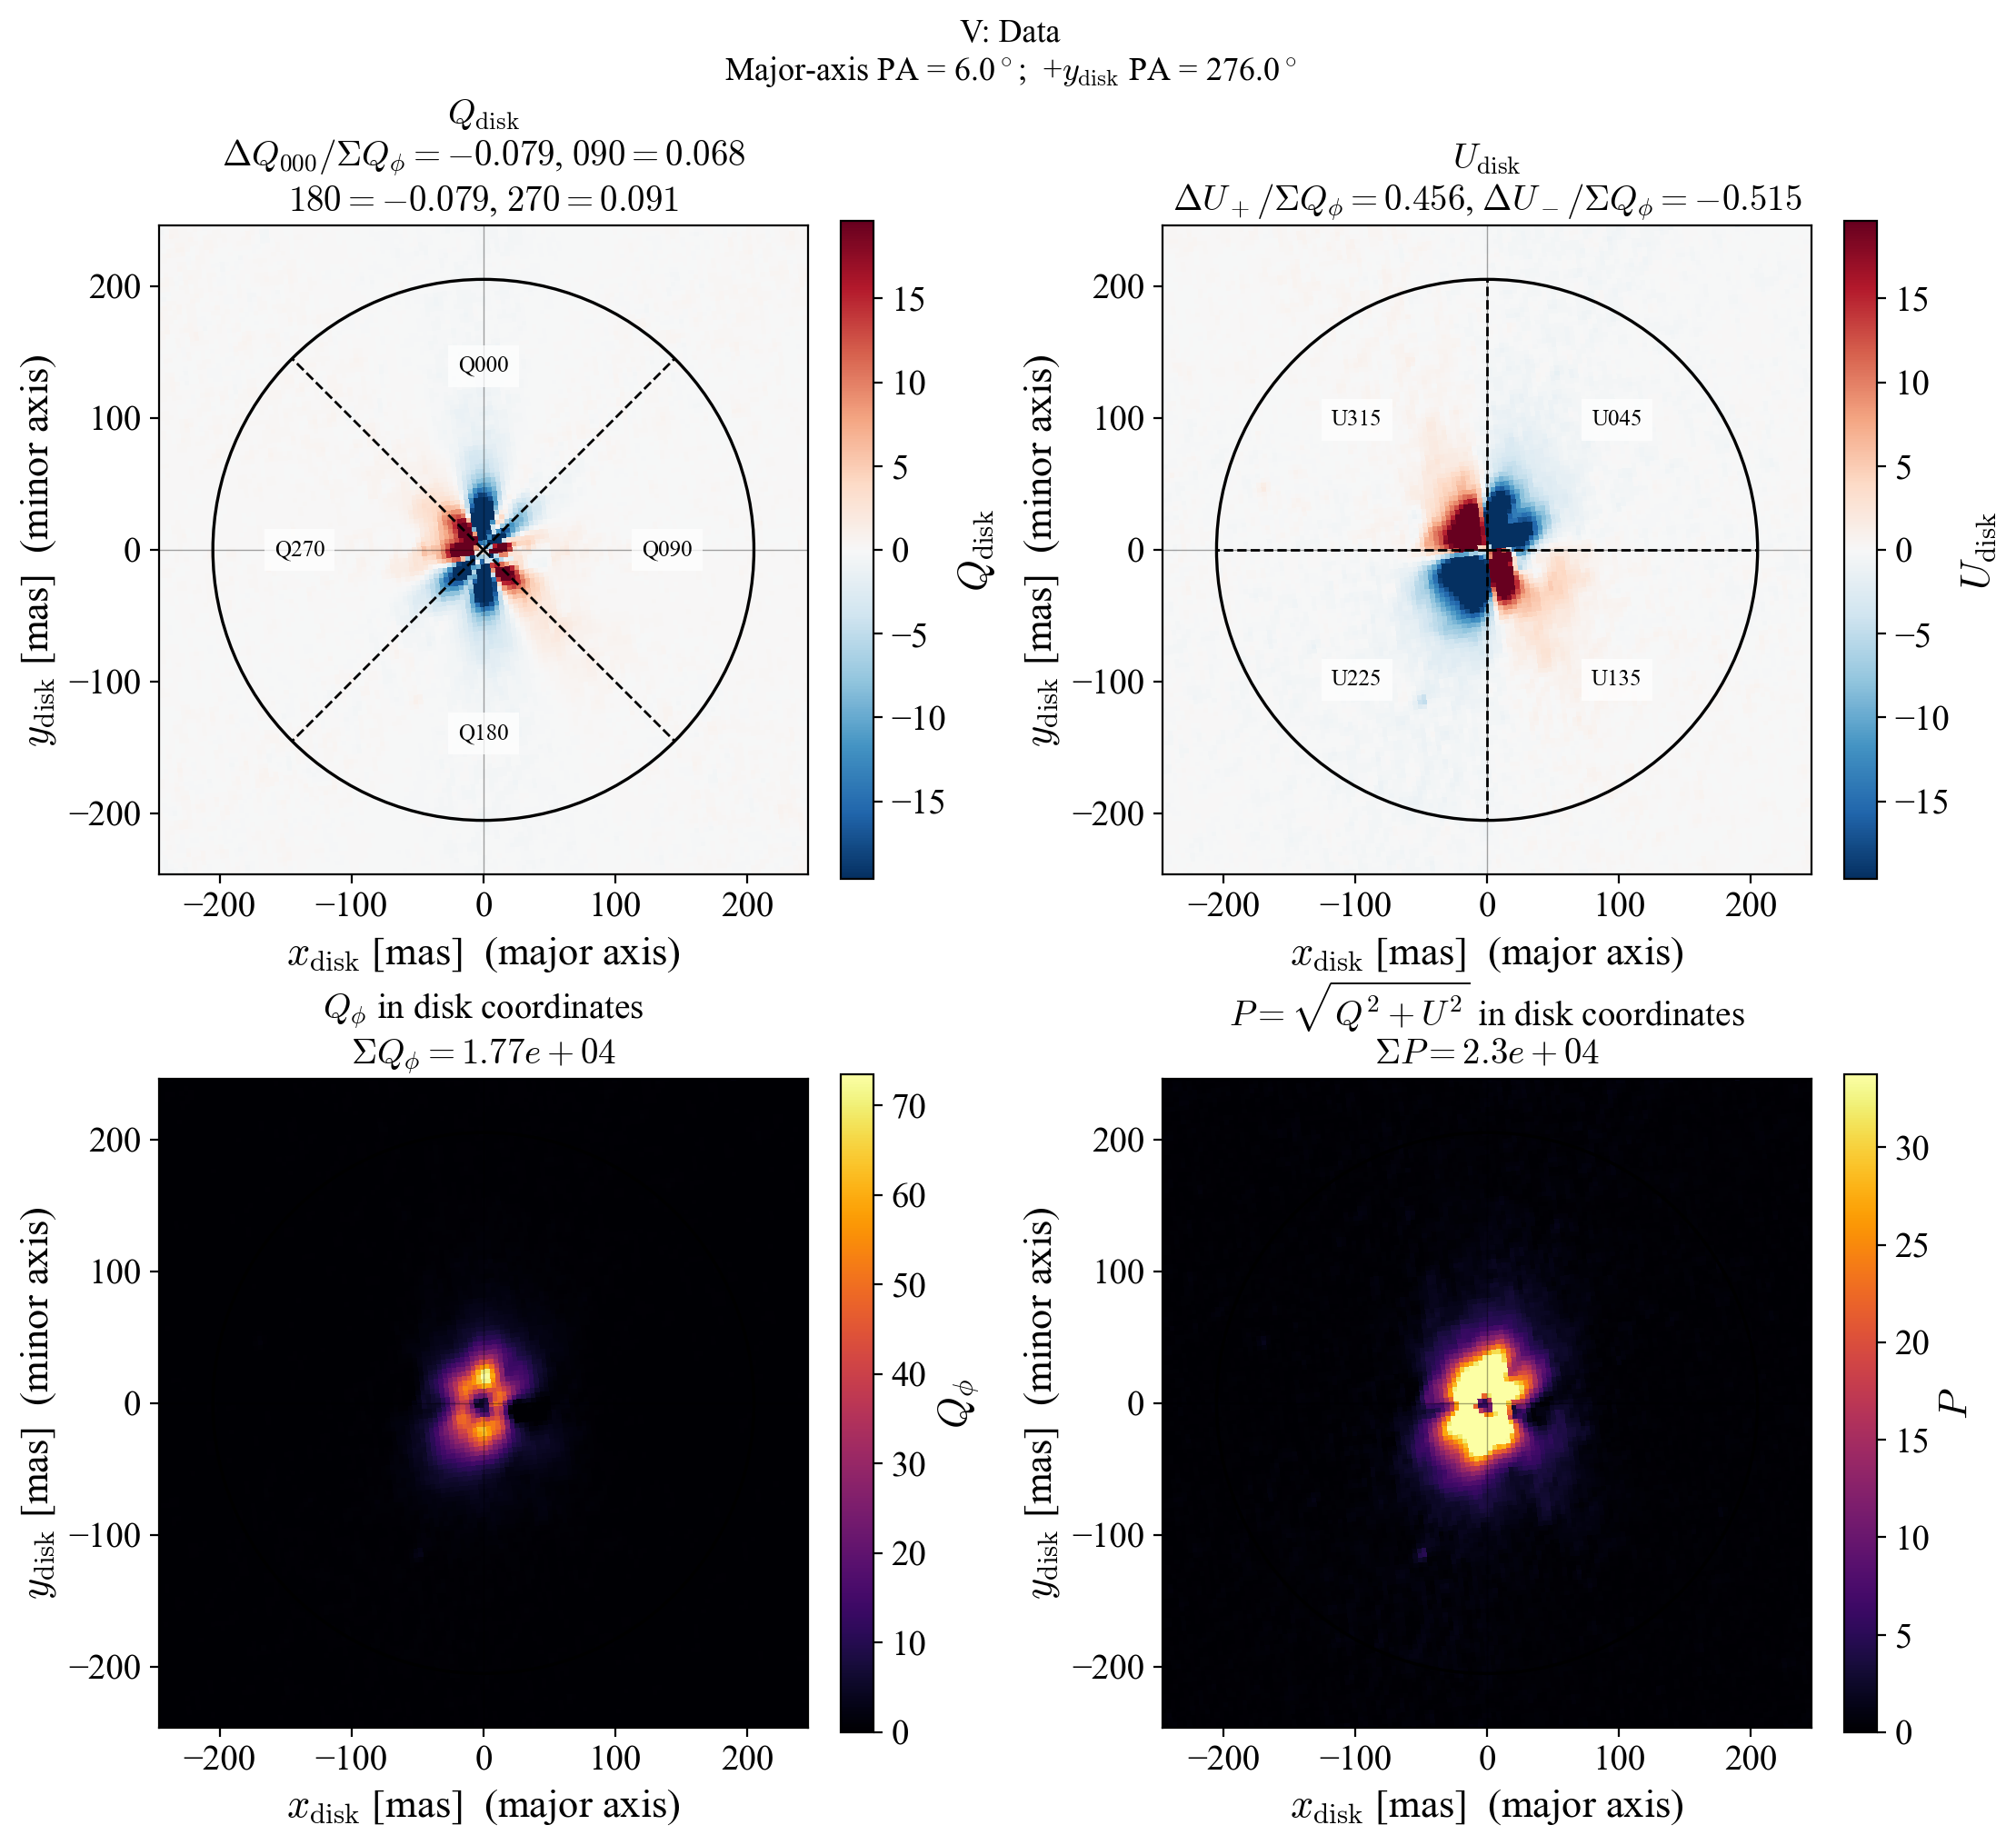

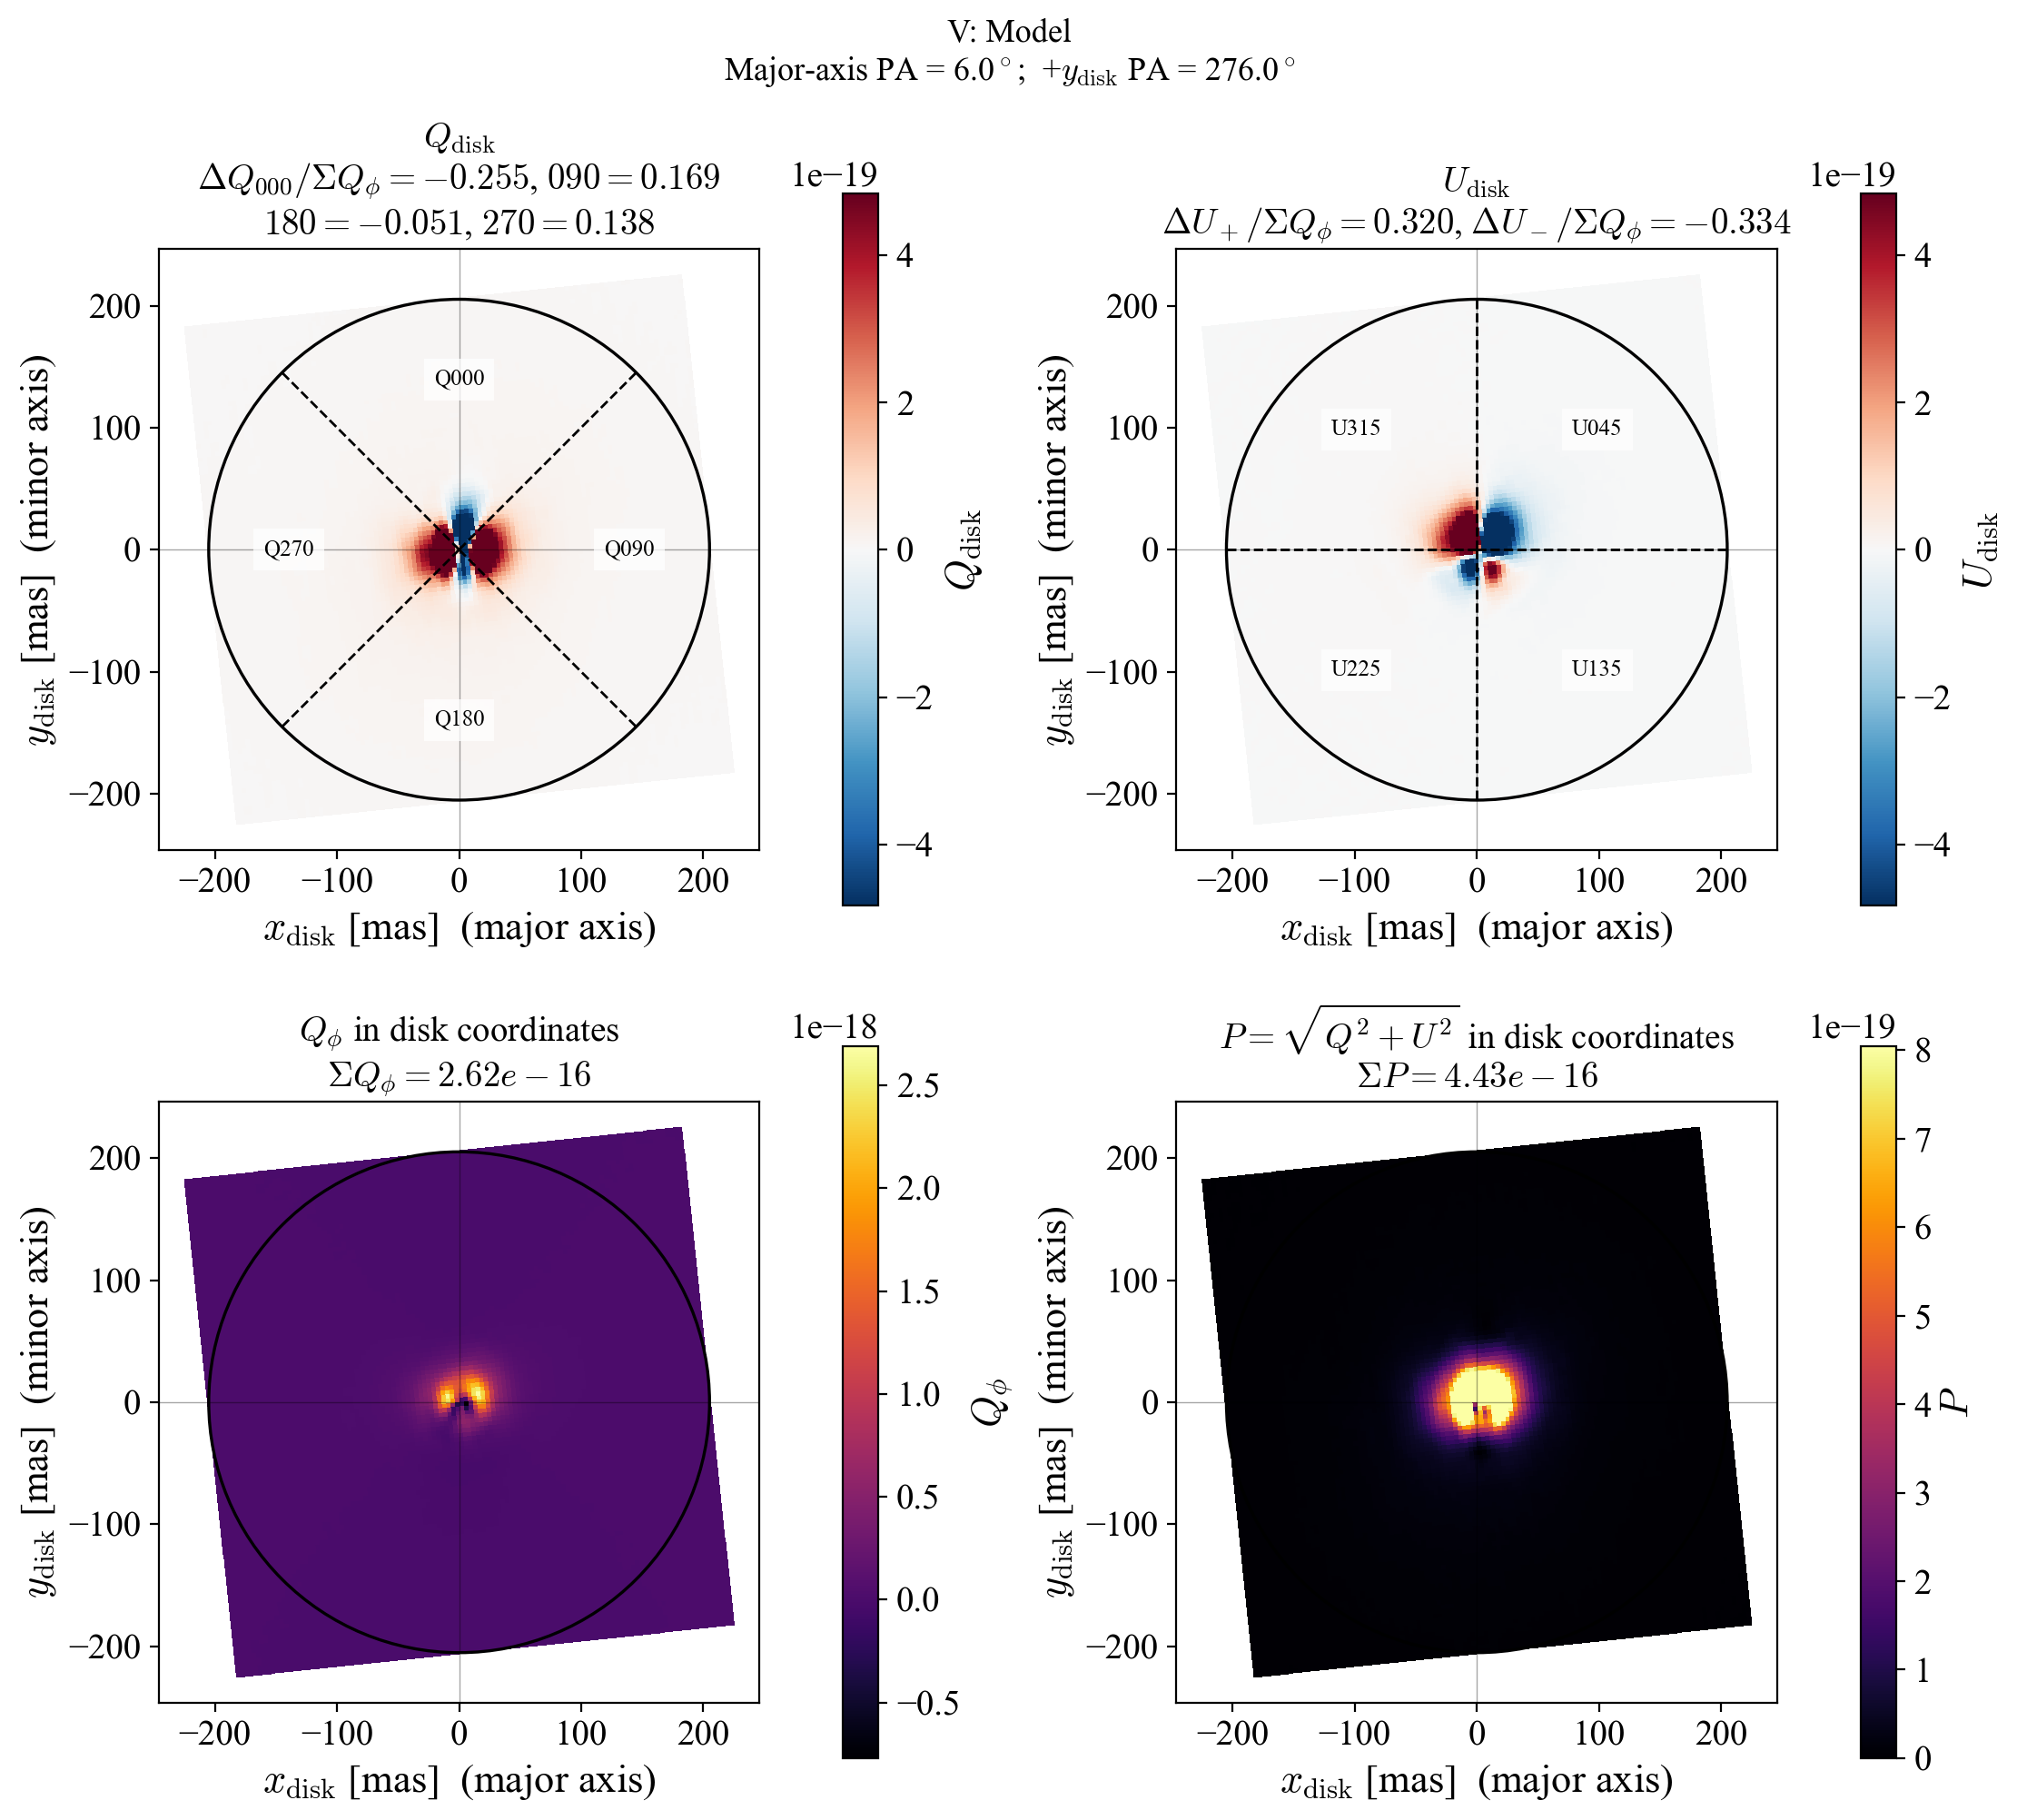

V: quadrant diagnostics match scoring; radius=205.2 mas, PA=6 deg.


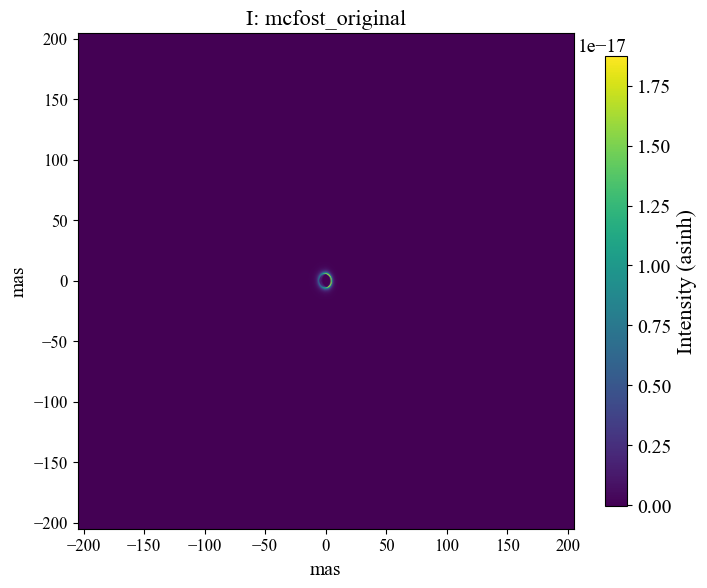

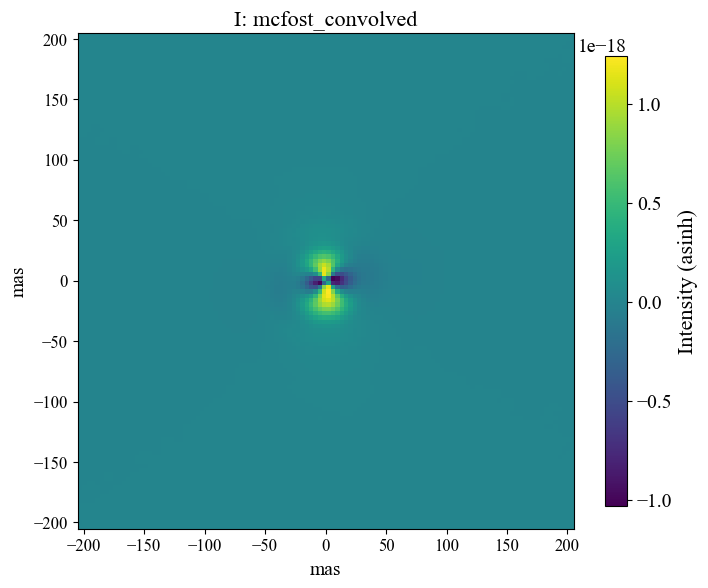

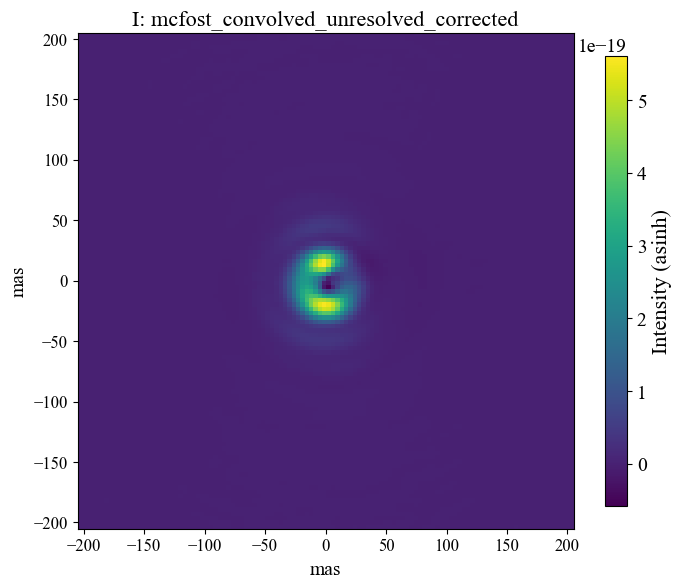

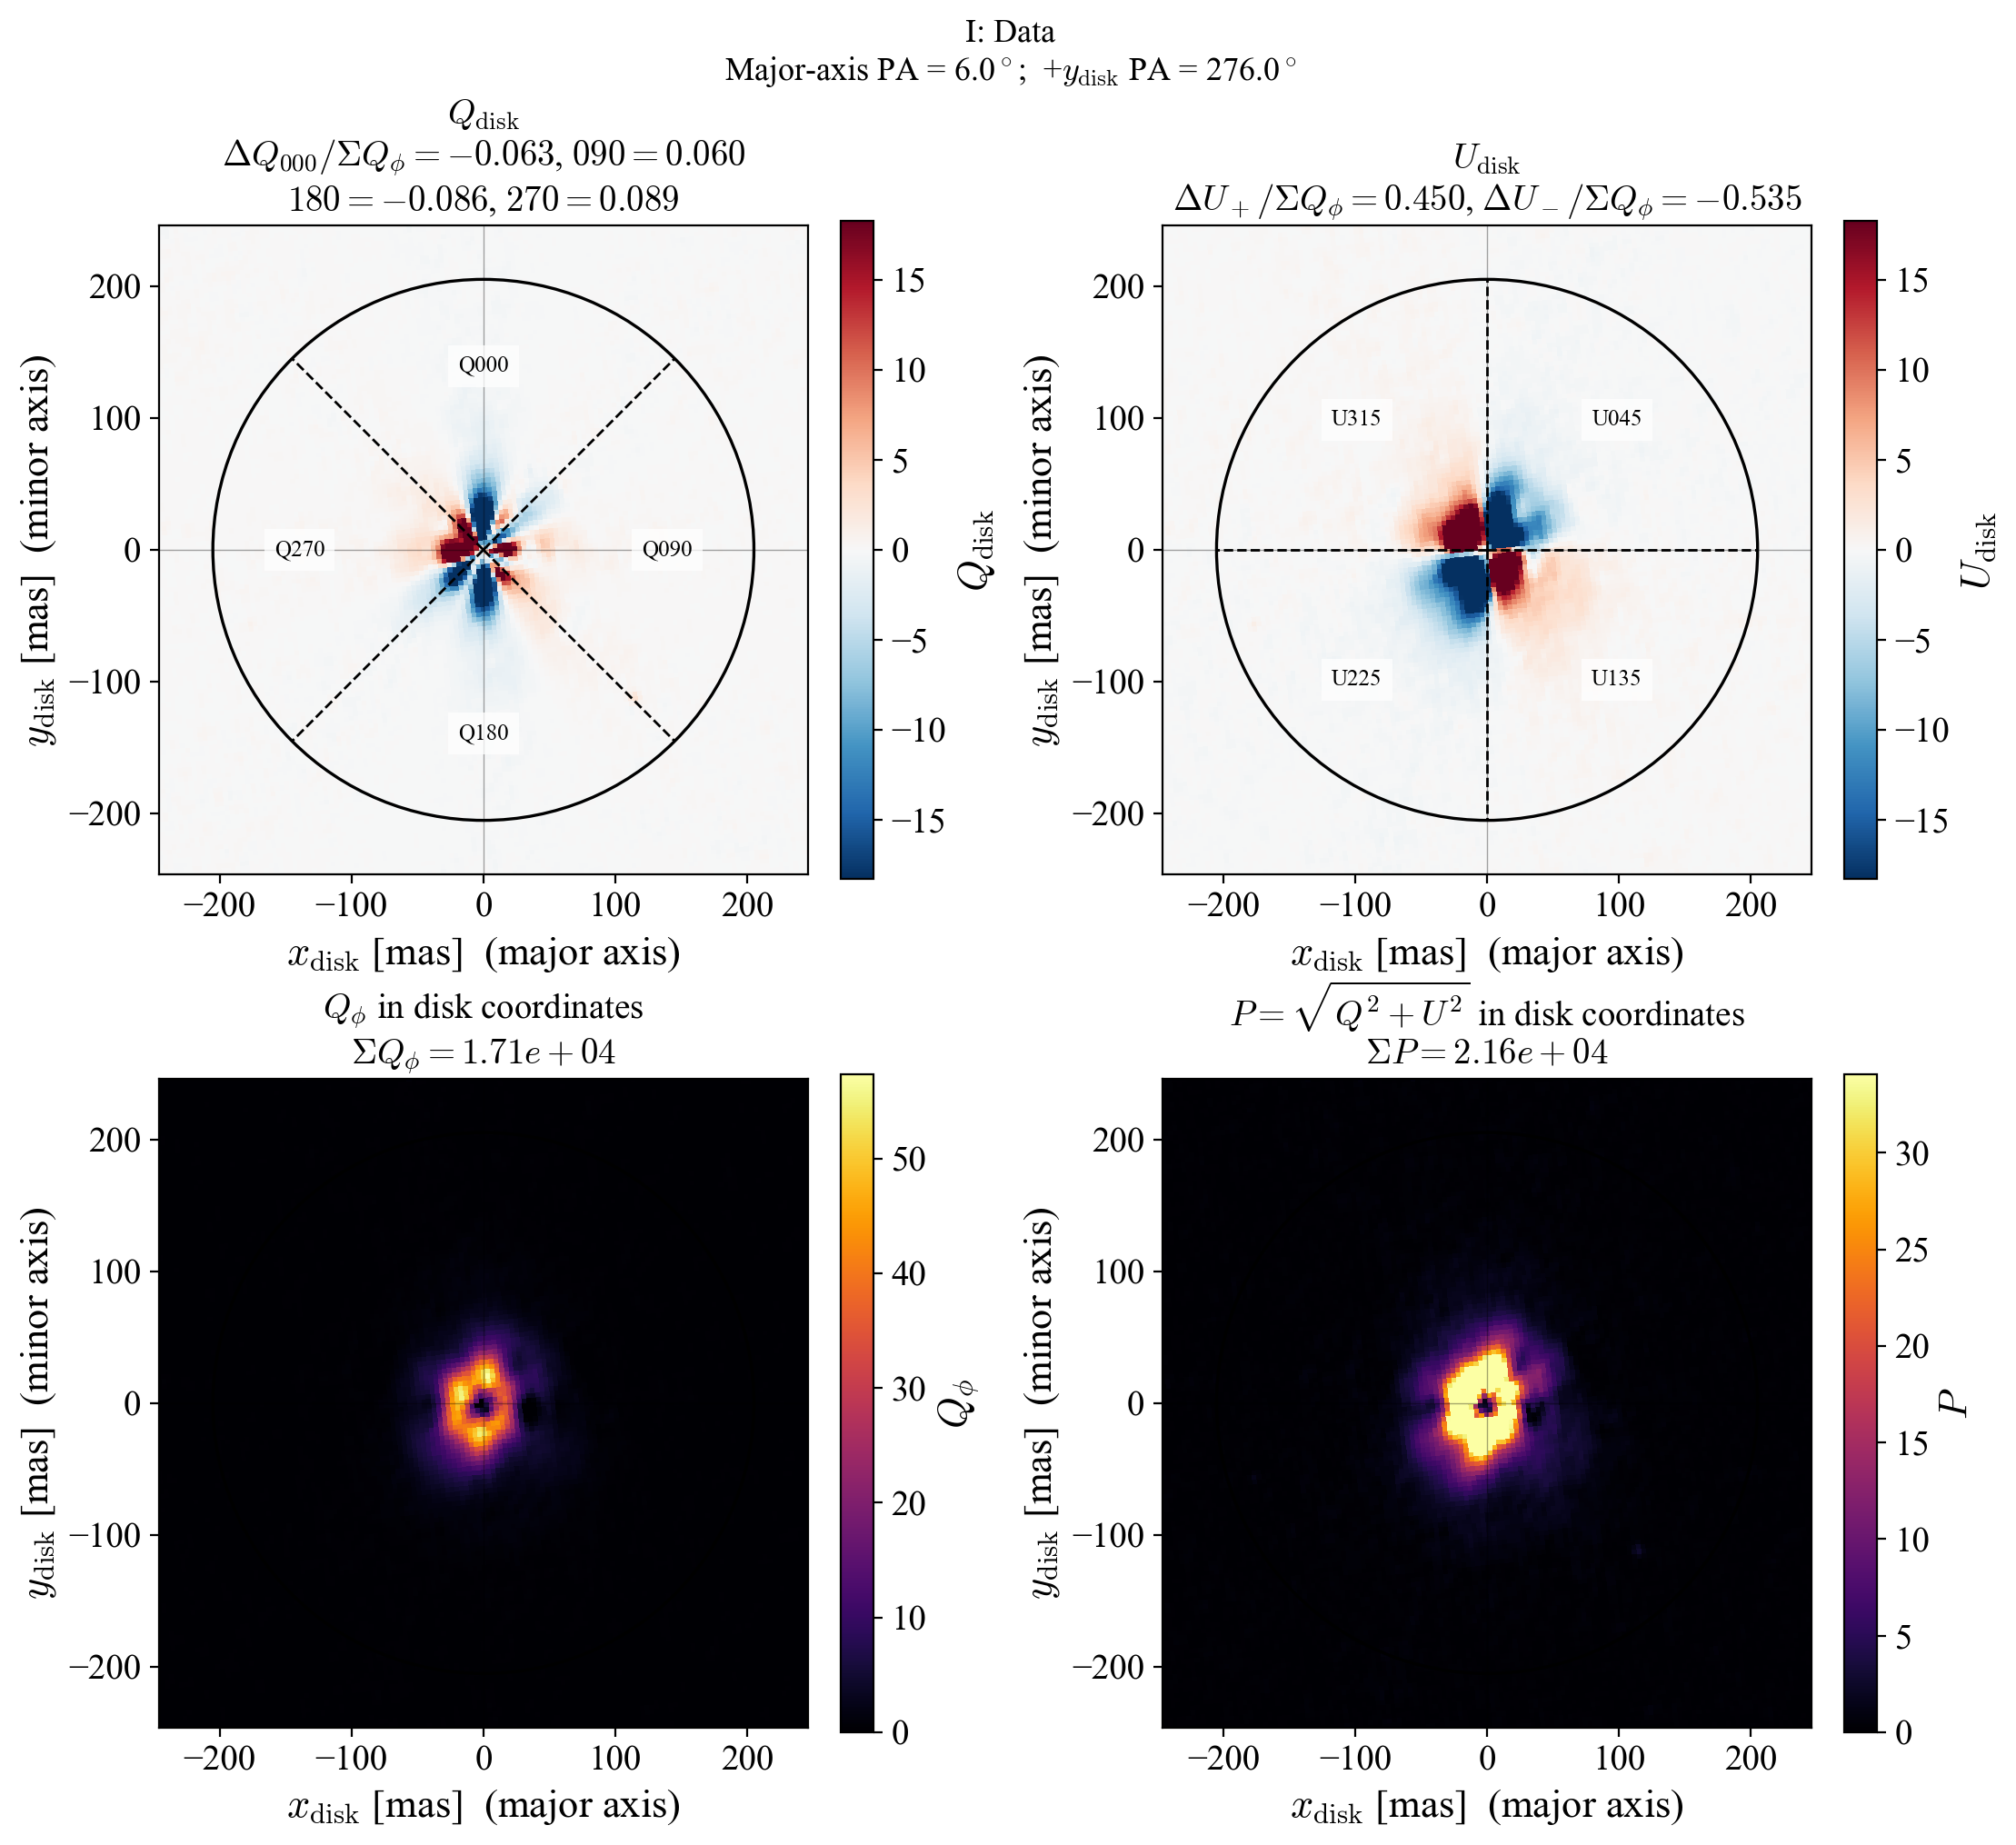

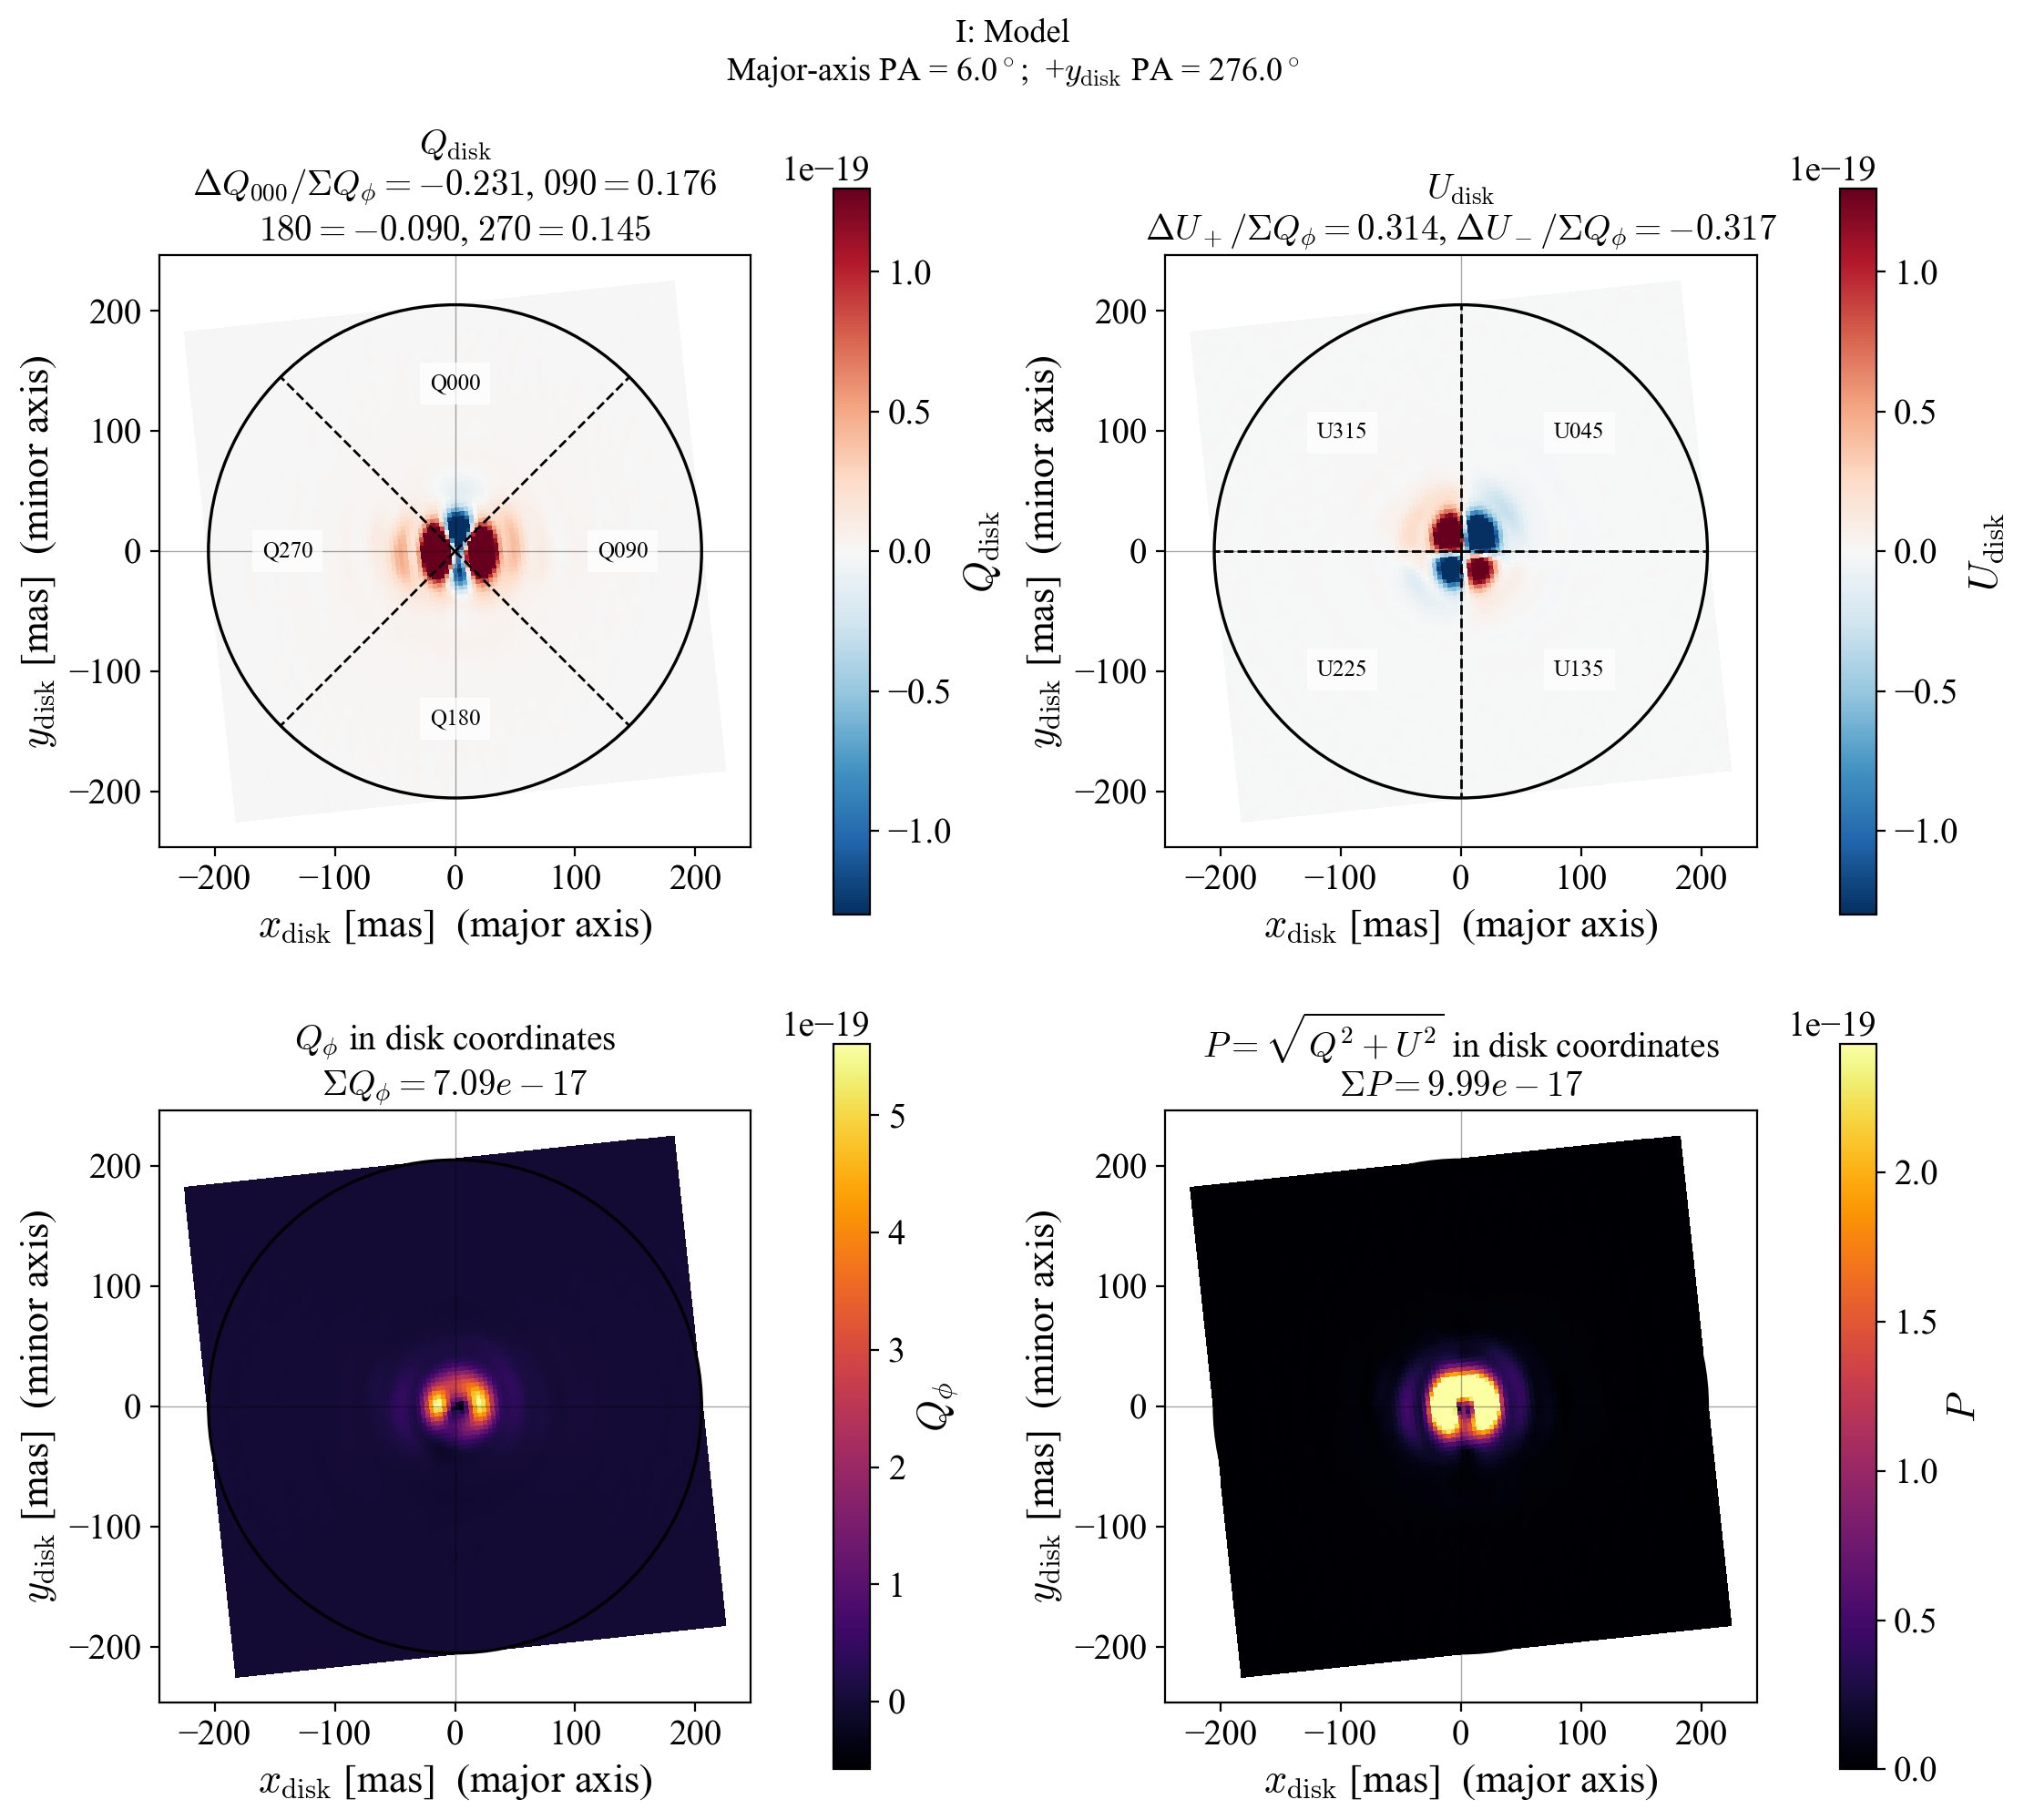

I: quadrant diagnostics match scoring; radius=205.2 mas, PA=6 deg.


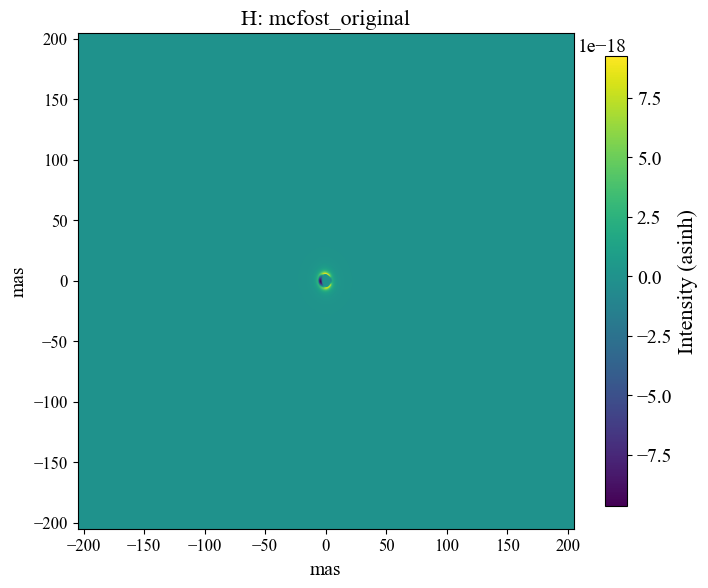

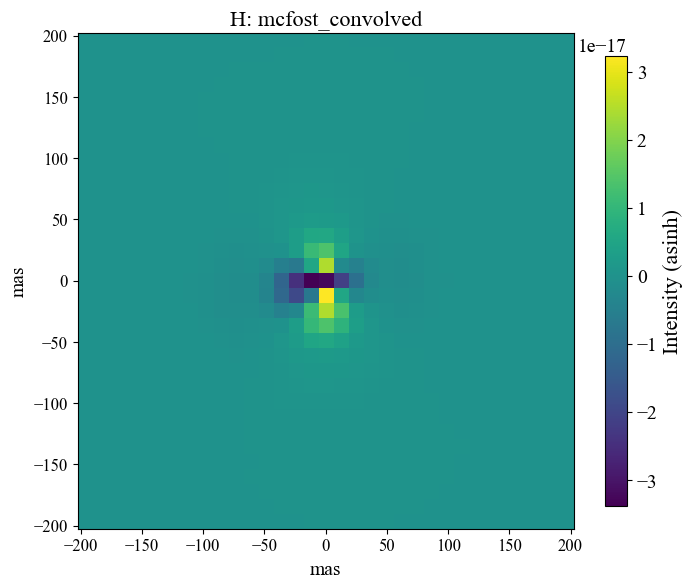

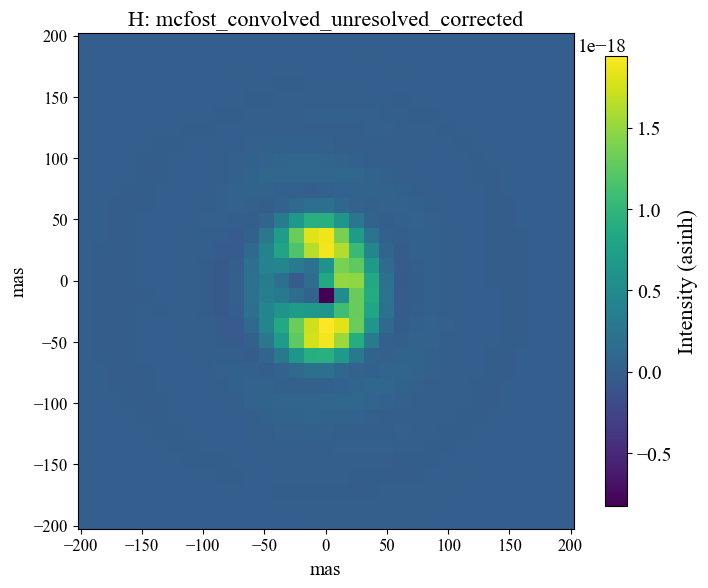

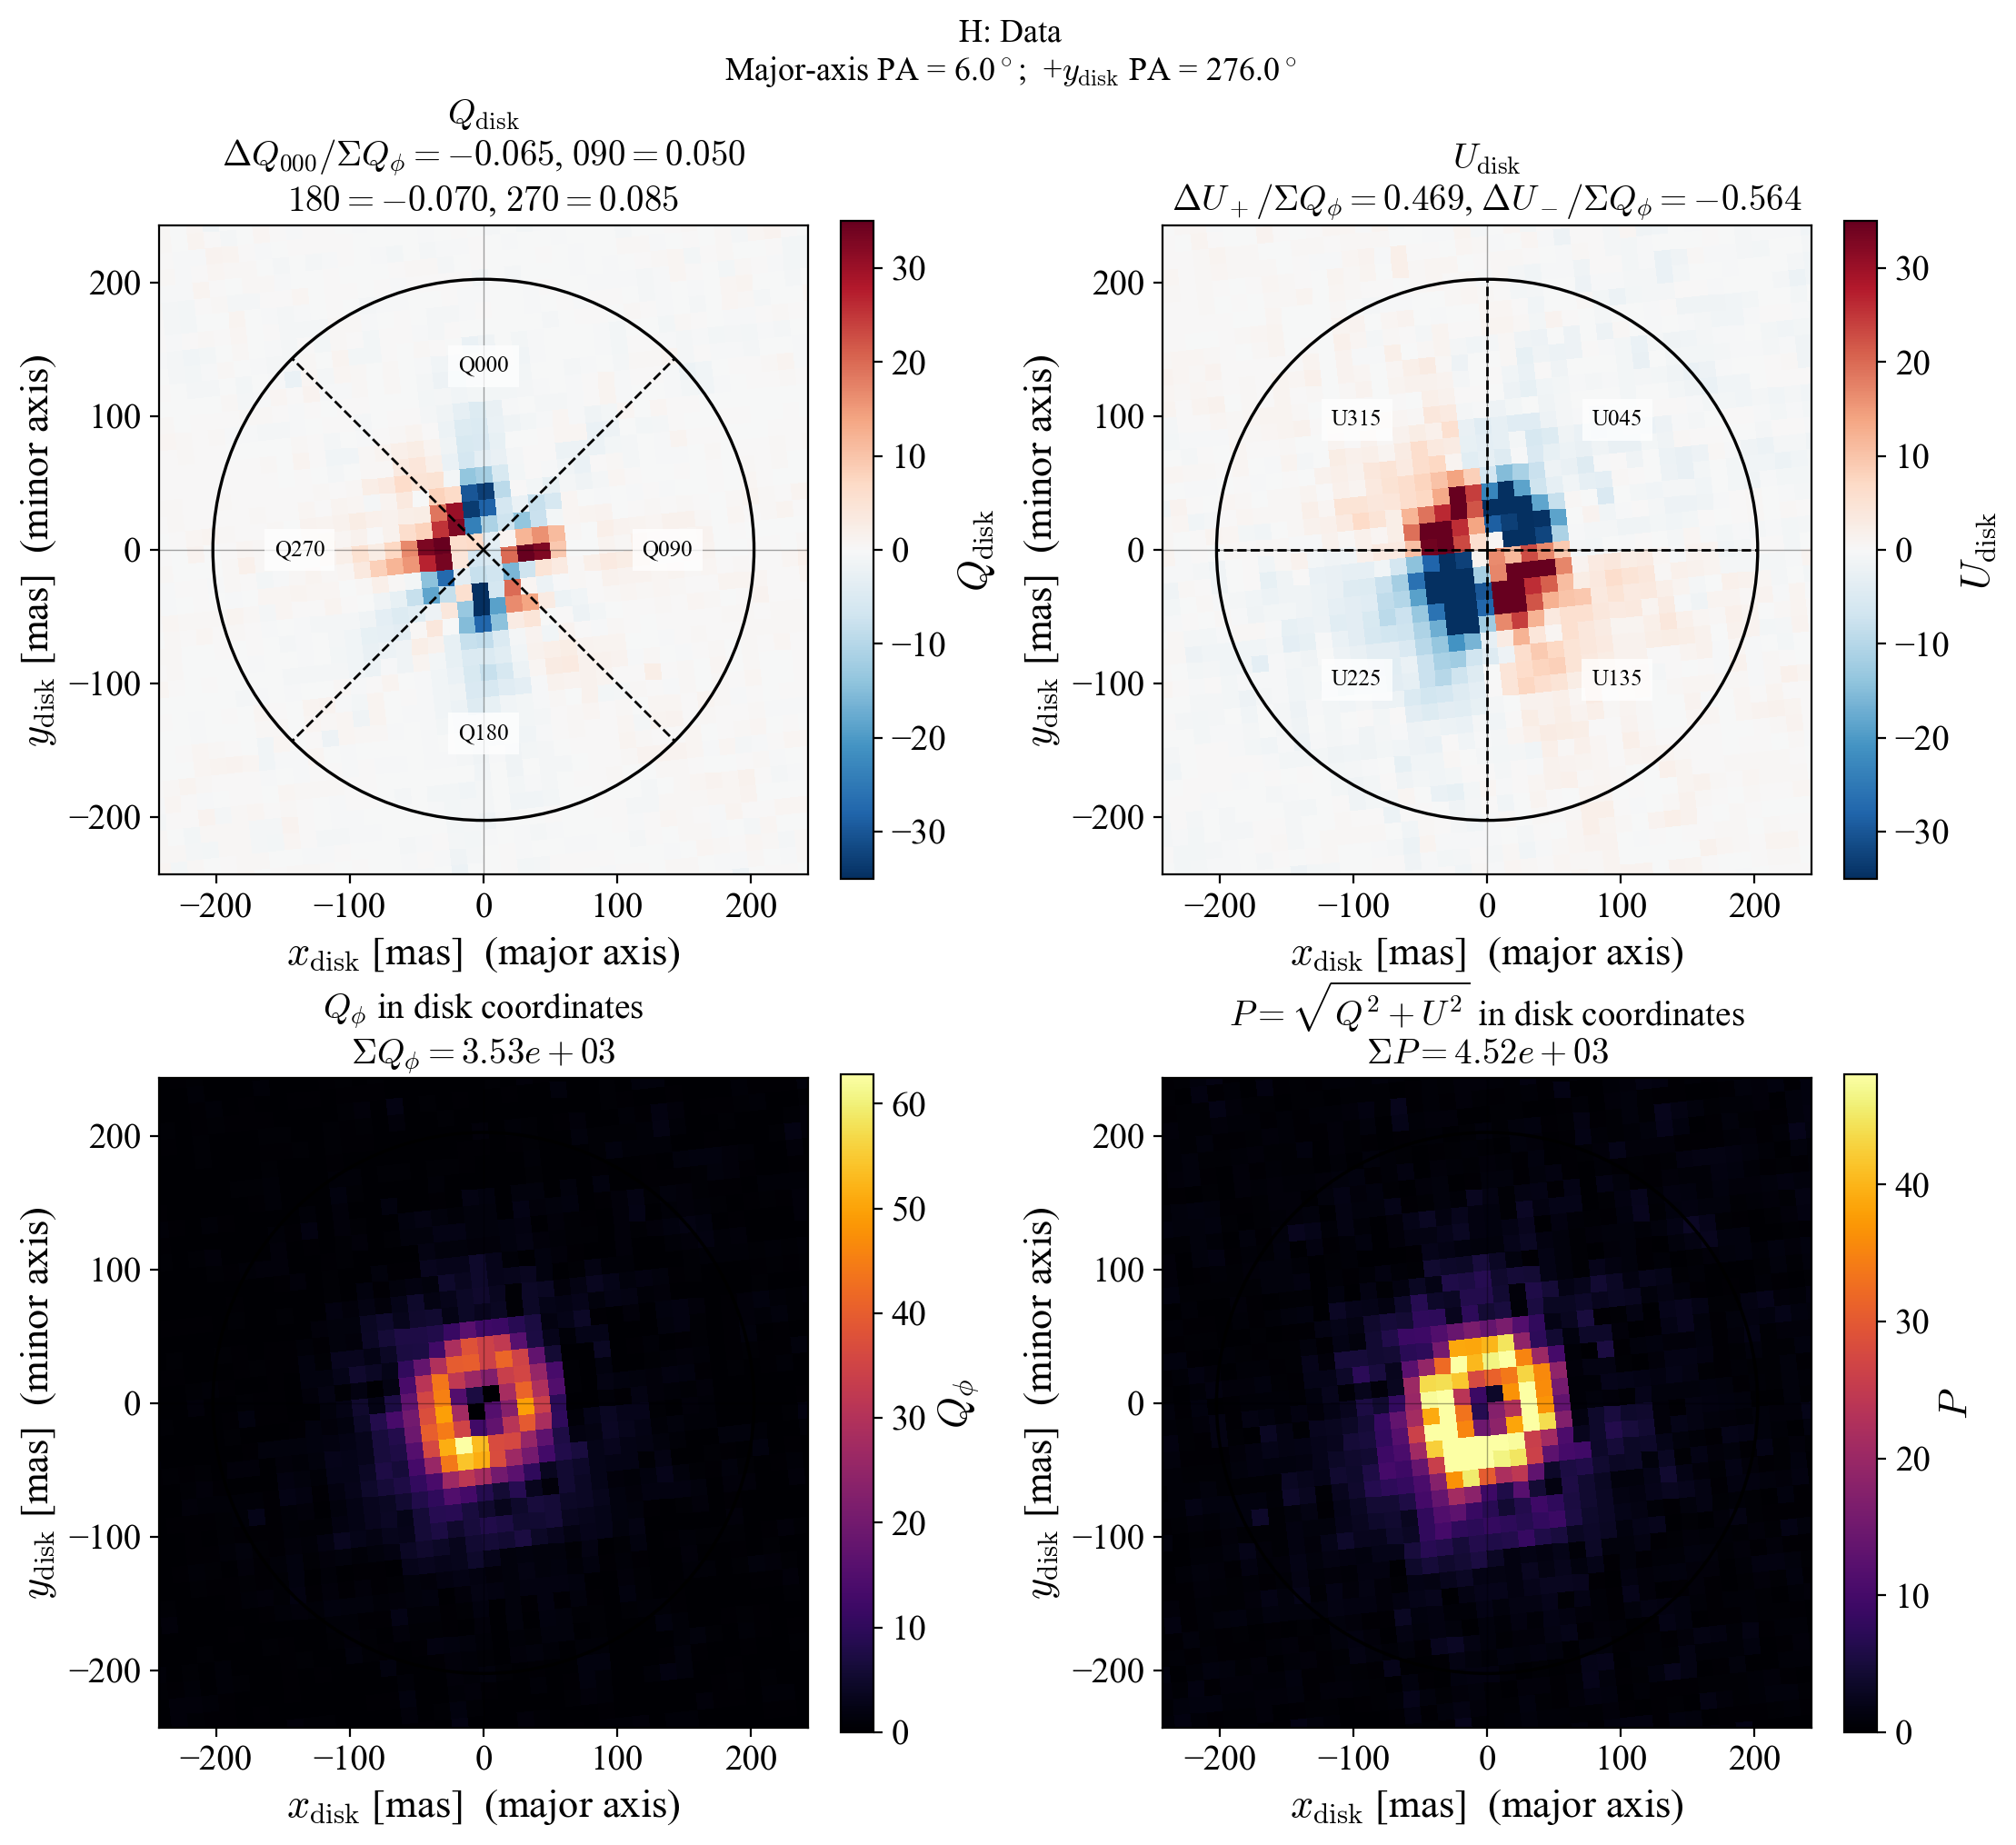

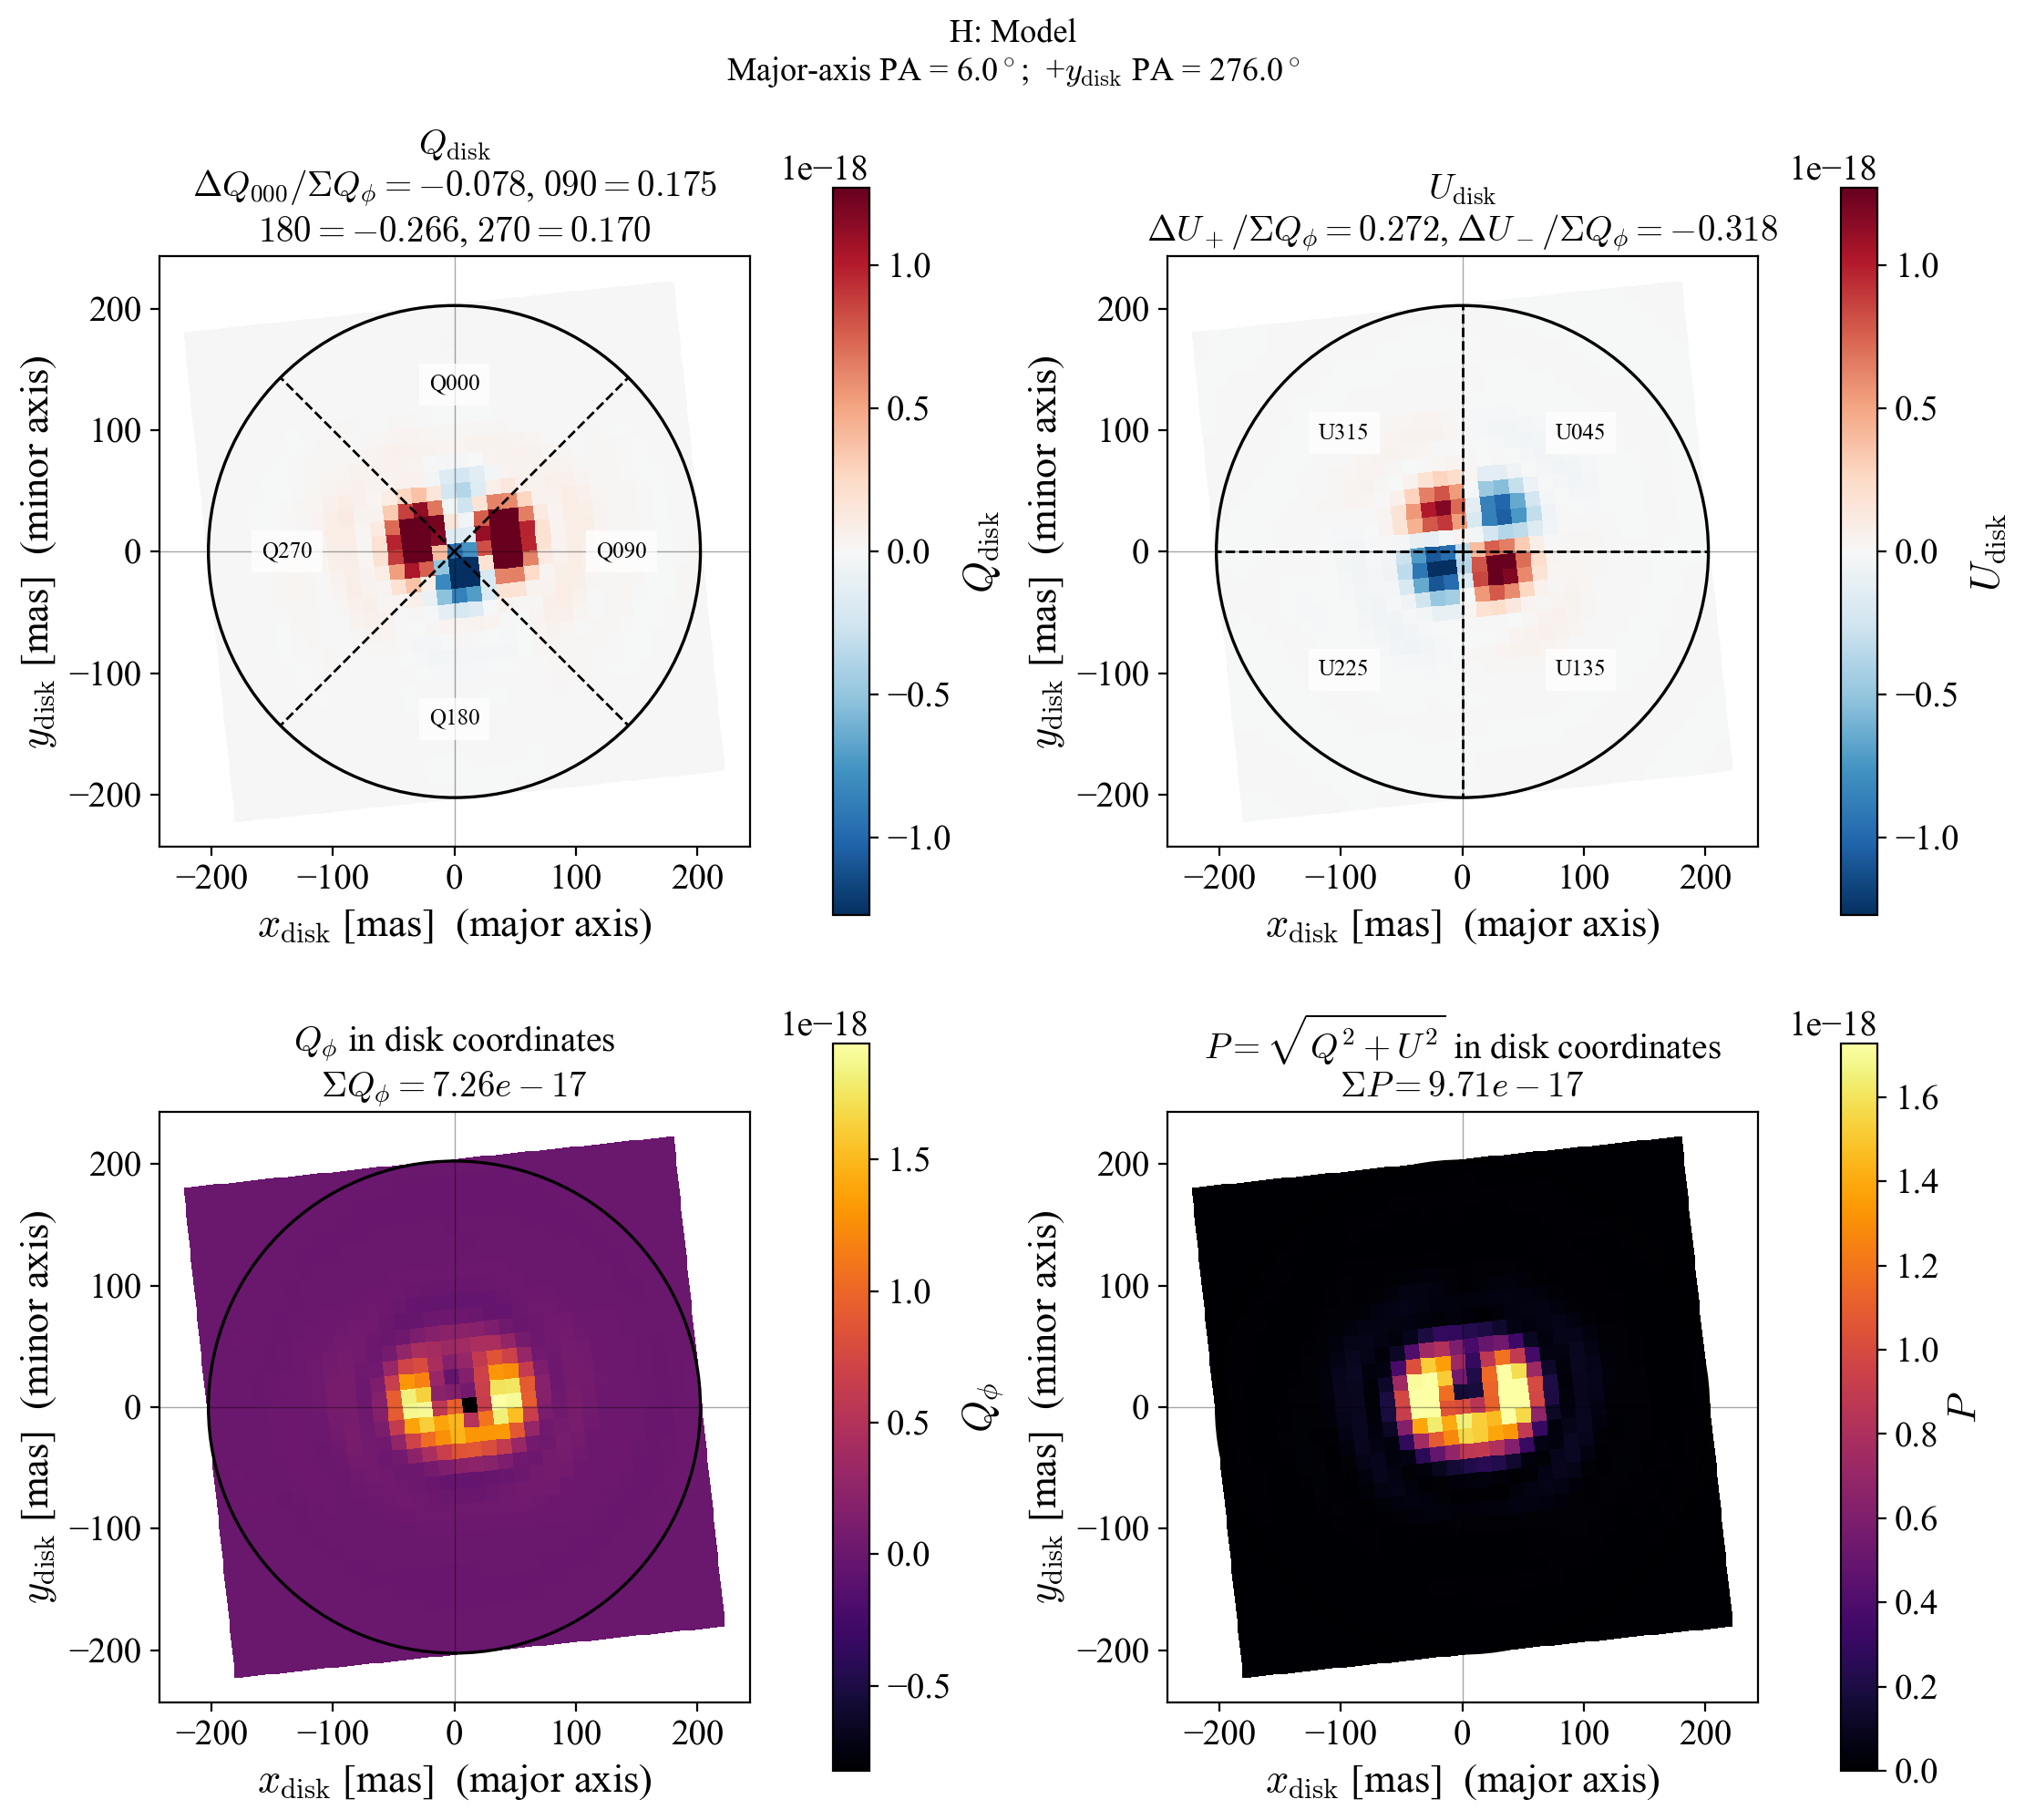

H: quadrant diagnostics match scoring; radius=202.455 mas, PA=6 deg.


In [15]:
SHOW_STAGE_IMAGES = True
SHOW_QUADRANT_MAPS = True
if not real_results:
    print('No completed model comparisons available for diagnostics.')
for (index, band), result in real_results.items():
    prepared = prepared_models[(index, band)]
    slot, _, _ = SETUP[band]
    target = OUTPUT / f'model_{index}_{band}'
    model = prepared[key]
    ps = model['pixel_scale_mas']
    if SHOW_STAGE_IMAGES:
        for stage in ('mcfost_original', 'mcfost_convolved', 'mcfost_convolved_unresolved_corrected'):
            image_path = target / f'{stage}_qphi.png'
            with obg.diagnostic_plot(f'{band}: {stage} Qphi'):
                obp.plot_polarimetric_image(
                    prepared[stage]['q_phi'], prepared[stage]['pixel_scale_mas'],
                    title=f'{band}: {stage}', image_scale='asinh',
                    save=str(image_path), show=False)
                display(Image(filename=str(image_path)))
    # Match compare_pdi_constraints(): derive observation Q/U from its scored Qphi/Uphi.
    pol = data[slot]['pol_images']
    _, _, _, phi_observed = obp.compute_qphi_uphi_pi(pol['Q_phi'], pol['U_phi'])
    c, s = np.cos(2*phi_observed), np.sin(2*phi_observed)
    observed_q = -pol['Q_phi']*c + pol['U_phi']*s
    observed_u = -pol['Q_phi']*s - pol['U_phi']*c
    for label, q, u, measured in (
        ('Data', observed_q, observed_u, result['observed']),
        ('Model', model['img_q'], model['img_u'], result['model'])):
        quadrants = obp.differential_quadrants(
            q, u, ps, result['disk_pa_deg'], 0., result['aperture_radius_mas'], plot=False)
        np.testing.assert_allclose([quadrants[k] for k in obp.PDI_QUADRANT_KEYS],
                                   measured['quadrants'], rtol=1e-10, atol=1e-12)
        if SHOW_QUADRANT_MAPS:
            image_path = target / f'{label.lower()}_scored_quadrants.png'
            with obg.diagnostic_plot(f'{band}: {label} scored quadrant maps'):
                obp.differential_quadrants(
                    q, u, ps, result['disk_pa_deg'], 0., result['aperture_radius_mas'],
                    plot=True, show=False, save=str(image_path), title=f'{band}: {label}')
                if image_path.is_file():
                    display(Image(filename=str(image_path)))
    print(f'{band}: quadrant diagnostics match scoring; radius={result["aperture_radius_mas"]:g} mas, PA={result["disk_pa_deg"]:g} deg.')

## Interpretation
Inspect whether fraction, radial shape, or quadrants dominate. The quadrant term sums six components; the radial term averages bins. A common flux scaling is intentionally invisible to these normalised PDI observables. Positive-only Qphi in the fraction retains its upward noise contribution. Synthetic sensitivity does not establish observational uncertainties.

Compare `loss` with the recorded SED, interferometry and ALMA contributions from the same model before deciding on future weights. No automatic reweighting is performed here.